<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Developer_Stress_Simulation_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Developer Stress Simulation Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mabubakrsiddiq/developer-stress-simulation-dataset

# Unziping the downloaded file
!unzip developer-stress-simulation-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mabubakrsiddiq/developer-stress-simulation-dataset
License(s): apache-2.0
  0% 0.00/7.80k [00:00<?, ?B/s]
100% 7.80k/7.80k [00:00<00:00, 28.4MB/s]
Archive:  developer-stress-simulation-dataset.zip
  inflating: developer_stress.csv    


# Data Inspection

In [3]:
df = pd.read_csv('developer_stress.csv')
df.head(11)

,Hours_Worked,Sleep_Hours,Bugs,Deadline_Days,Coffee_Cups,Meetings,Interruptions,Experience_Years,Code_Complexity,Remote_Work,Stress_Level
0,10,8,25,53,4,9,2,Senior,Medium,Yes,58.521033
1,7,8,33,33,2,6,9,Junior,Medium,Yes,47.461651
2,14,8,44,54,10,12,2,Junior,Low,No,59.211580
3,11,6,5,46,0,13,9,Mid,Low,Yes,100.000000
4,8,7,36,23,9,3,2,Junior,Medium,Yes,28.784957
5,10,6,32,53,5,7,4,Senior,Medium,No,68.798863
6,13,4,21,21,1,4,4,Senior,High,No,100.000000
7,6,4,20,4,2,0,3,Mid,Medium,Yes,100.000000
8,10,7,5,55,0,3,0,Junior,Medium,Yes,42.817044
9,14,6,5,32,8,2,4,Junior,Medium,No,46.183850


In [18]:
# Let's check the data types and info of the new DataFrame
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Hours_Worked              500 non-null    int64  
 1   Sleep_Hours               500 non-null    int64  
 2   Bugs                      500 non-null    int64  
 3   Deadline_Days             500 non-null    int64  
 4   Coffee_Cups               500 non-null    int64  
 5   Meetings                  500 non-null    int64  
 6   Interruptions             500 non-null    int64  
 7   Experience_Years          500 non-null    object 
 8   Code_Complexity           500 non-null    object 
 9   Stress_Level              500 non-null    float64
 10  Experience_Years_Encoded  500 non-null    int64  
 11  Code_Complexity_Encoded   500 non-null    int64  
 12  Remote_Work_Encoded       500 non-null    bool   
 13  Bugs_Per_Hour_Worked      500 non-null    float64
 14  Coffee_Per

In [4]:
df.tail(11)

,Hours_Worked,Sleep_Hours,Bugs,Deadline_Days,Coffee_Cups,Meetings,Interruptions,Experience_Years,Code_Complexity,Remote_Work,Stress_Level
489,10,6,25,27,5,17,8,Senior,Low,No,100.000000
490,6,8,28,28,6,2,10,Junior,Low,Yes,13.926934
491,15,4,20,20,8,12,6,Mid,High,No,100.000000
492,13,3,10,46,0,10,6,Mid,Medium,Yes,100.000000
493,6,6,39,15,10,16,0,Senior,Medium,No,24.310410
494,8,5,10,36,6,12,3,Senior,Low,Yes,70.221640
495,9,4,35,58,7,5,1,Mid,Low,Yes,100.000000
496,12,3,48,19,2,16,1,Mid,Low,No,100.000000
497,15,7,38,5,3,12,1,Junior,Medium,Yes,87.110845
498,8,8,39,18,9,18,3,Mid,Low,Yes,51.088981


In [5]:
df.shape

(500, 11)

In [6]:
df.columns

Index(['Hours_Worked', 'Sleep_Hours', 'Bugs', 'Deadline_Days', 'Coffee_Cups',
       'Meetings', 'Interruptions', 'Experience_Years', 'Code_Complexity',
       'Remote_Work', 'Stress_Level'],
      dtype='object')

In [7]:
df.dtypes

,0
Hours_Worked,int64
Sleep_Hours,int64
Bugs,int64
Deadline_Days,int64
Coffee_Cups,int64
Meetings,int64
Interruptions,int64
Experience_Years,object
Code_Complexity,object
Remote_Work,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hours_Worked      500 non-null    int64  
 1   Sleep_Hours       500 non-null    int64  
 2   Bugs              500 non-null    int64  
 3   Deadline_Days     500 non-null    int64  
 4   Coffee_Cups       500 non-null    int64  
 5   Meetings          500 non-null    int64  
 6   Interruptions     500 non-null    int64  
 7   Experience_Years  500 non-null    object 
 8   Code_Complexity   500 non-null    object 
 9   Remote_Work       500 non-null    object 
 10  Stress_Level      500 non-null    float64
dtypes: float64(1), int64(7), object(3)
memory usage: 43.1+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Worked,500.0,NaN,NaN,NaN,9.504,3.543317,4.0,6.0,10.0,13.0,15.0
Sleep_Hours,500.0,NaN,NaN,NaN,5.436,1.706378,3.0,4.0,5.0,7.0,8.0
Bugs,500.0,NaN,NaN,NaN,25.15,14.909866,0.0,11.0,26.0,37.0,50.0
Deadline_Days,500.0,NaN,NaN,NaN,30.676,17.284691,0.0,16.0,31.0,45.0,60.0
Coffee_Cups,500.0,NaN,NaN,NaN,4.922,3.155286,0.0,2.0,5.0,8.0,10.0
Meetings,500.0,NaN,NaN,NaN,10.164,6.227573,0.0,5.0,10.0,16.0,20.0
Interruptions,500.0,NaN,NaN,NaN,4.968,3.074717,0.0,2.0,5.0,8.0,10.0
Experience_Years,500,3,Senior,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code_Complexity,500,3,Medium,206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Remote_Work,500,2,No,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
Hours_Worked,0
Sleep_Hours,0
Bugs,0
Deadline_Days,0
Coffee_Cups,0
Meetings,0
Interruptions,0
Experience_Years,0
Code_Complexity,0
Remote_Work,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Statistical Analysis

In [20]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

# --- T-test: Comparing Stress_Level between Remote_Work_Encoded groups ---
print("\n--- T-test: Stress Level by Remote Work ---")
remote_work_stress = df_fe[df_fe['Remote_Work_Encoded'] == True]['Stress_Level']
non_remote_work_stress = df_fe[df_fe['Remote_Work_Encoded'] == False]['Stress_Level']

t_stat, p_value = ttest_ind(remote_work_stress, non_remote_work_stress)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a statistically significant difference in stress level between remote and non-remote workers.")
else:
    print("There is no statistically significant difference in stress level between remote and non-remote workers.")

# --- ANOVA: Comparing Stress_Level across Experience_Years_Encoded groups ---

print("\n--- ANOVA: Stress Level by Experience Years ---")
junior_stress = df_fe[df_fe['Experience_Years_Encoded'] == 0]['Stress_Level']
mid_stress = df_fe[df_fe['Experience_Years_Encoded'] == 1]['Stress_Level']
senior_stress = df_fe[df_fe['Experience_Years_Encoded'] == 2]['Stress_Level']

f_stat, p_value = f_oneway(junior_stress, mid_stress, senior_stress)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a statistically significant difference in stress level across different experience levels.")
else:
    print("There is no statistically significant difference in stress level across different experience levels.")

# --- Chi-Square Test: Relationship between Experience_Years_Encoded and Remote_Work_Encoded ---
print("\n--- Chi-Square Test: Experience Years vs. Remote Work ---")
contingency_table = pd.crosstab(df_fe['Experience_Years_Encoded'], df_fe['Remote_Work_Encoded'])
print("Contingency Table:\n", contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a statistically significant association between experience years and remote work status.")
else:
    print("There is no statistically significant association between experience years and remote work status.")


--- T-test: Stress Level by Remote Work ---
T-statistic: -0.805
P-value: 0.421
There is no statistically significant difference in stress level between remote and non-remote workers.

--- ANOVA: Stress Level by Experience Years ---
F-statistic: 3.069
P-value: 0.047
There is a statistically significant difference in stress level across different experience levels.

--- Chi-Square Test: Experience Years vs. Remote Work ---
Contingency Table:
 Remote_Work_Encoded       False  True 
Experience_Years_Encoded              
0                            72     64
1                            90     87
2                            93     94
Chi-square statistic: 0.327
P-value: 0.849
There is no statistically significant association between experience years and remote work status.


# Feature Engineering

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Making a copy to avoid modifying the original DataFrame directly
df_fe = df.copy()

# 1. Encoding Categorical Variables

# Ordinal Encoding for Experience_Years
experience_mapping = {'Junior': 0, 'Mid': 1, 'Senior': 2}
df_fe['Experience_Years_Encoded'] = df_fe['Experience_Years'].map(experience_mapping)

# Ordinal Encoding for Code_Complexity
complexity_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_fe['Code_Complexity_Encoded'] = df_fe['Code_Complexity'].map(complexity_mapping)

# One-Hot Encoding for Remote_Work
df_fe = pd.get_dummies(df_fe, columns=['Remote_Work'], drop_first=True)
df_fe.rename(columns={'Remote_Work_Yes': 'Remote_Work_Encoded'}, inplace=True)

# 2. Creating Interaction and Ratio Features

# Bugs per hour worked (handling division by zero)
df_fe['Bugs_Per_Hour_Worked'] = df_fe.apply(lambda row: row['Bugs'] / row['Hours_Worked'] if row['Hours_Worked'] != 0 else 0, axis=1)

# Coffee consumption relative to sleep hours
df_fe['Coffee_Per_Sleep_Hour'] = df_fe.apply(lambda row: row['Coffee_Cups'] / row['Sleep_Hours'] if row['Sleep_Hours'] != 0 else 0, axis=1)

# Work-Life Balance Ratio (Hours Worked vs. Sleep Hours)
df_fe['Work_Life_Balance_Ratio'] = df_fe.apply(lambda row: row['Hours_Worked'] / (row['Hours_Worked'] + row['Sleep_Hours']) if (row['Hours_Worked'] + row['Sleep_Hours']) != 0 else 0, axis=1)

# Display the first few rows with new features
display(df_fe.head())

,Hours_Worked,Sleep_Hours,Bugs,Deadline_Days,Coffee_Cups,Meetings,Interruptions,Experience_Years,Code_Complexity,Stress_Level,Experience_Years_Encoded,Code_Complexity_Encoded,Remote_Work_Encoded,Bugs_Per_Hour_Worked,Coffee_Per_Sleep_Hour,Work_Life_Balance_Ratio
0,10,8,25,53,4,9,2,Senior,Medium,58.521033,2,1,True,2.500000,0.500000,0.555556
1,7,8,33,33,2,6,9,Junior,Medium,47.461651,0,1,True,4.714286,0.250000,0.466667
2,14,8,44,54,10,12,2,Junior,Low,59.211580,0,0,False,3.142857,1.250000,0.636364
3,11,6,5,46,0,13,9,Mid,Low,100.000000,1,0,True,0.454545,0.000000,0.647059
4,8,7,36,23,9,3,2,Junior,Medium,28.784957,0,1,True,4.500000,1.285714,0.533333


# Univariate Analysis

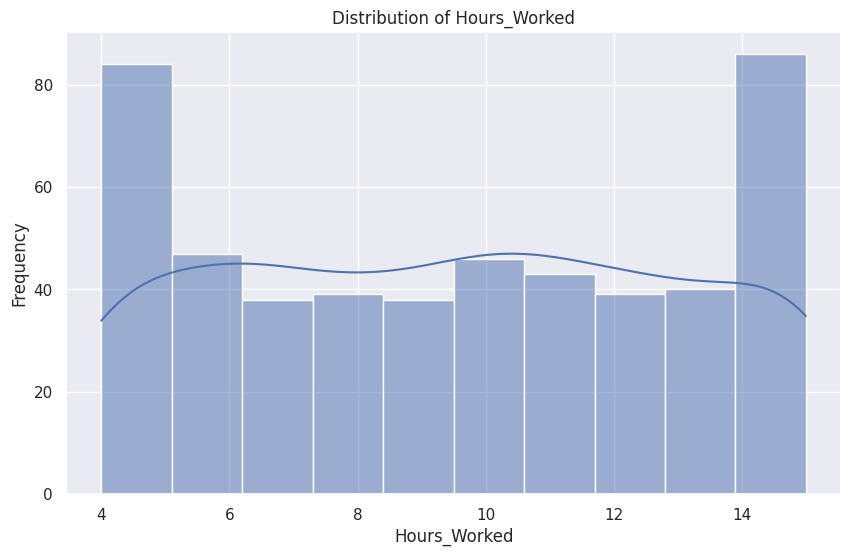

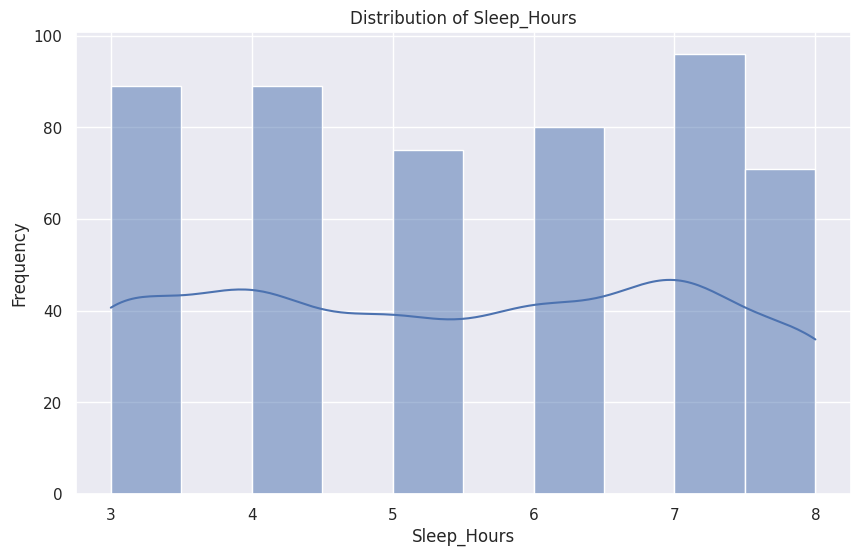

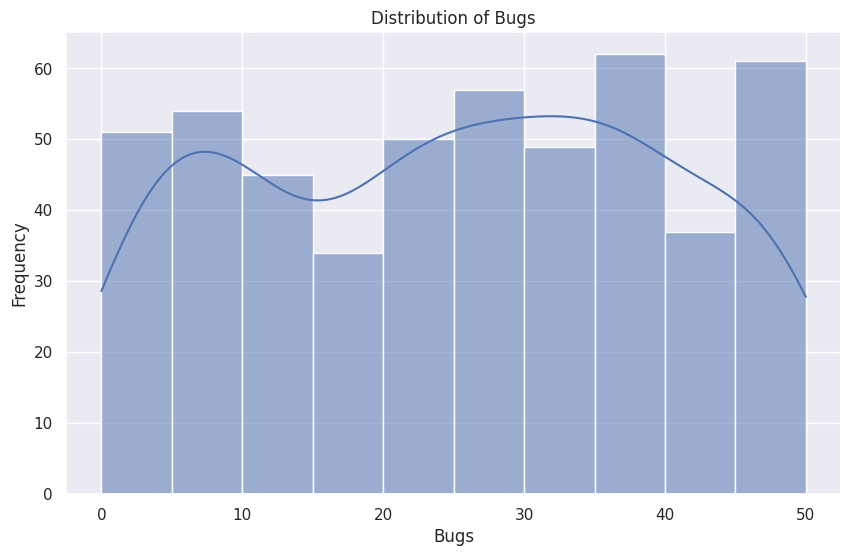

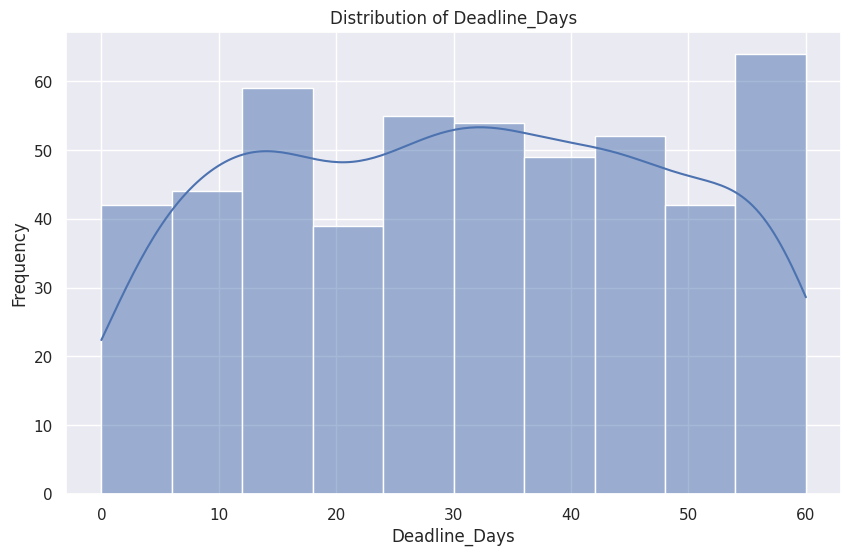

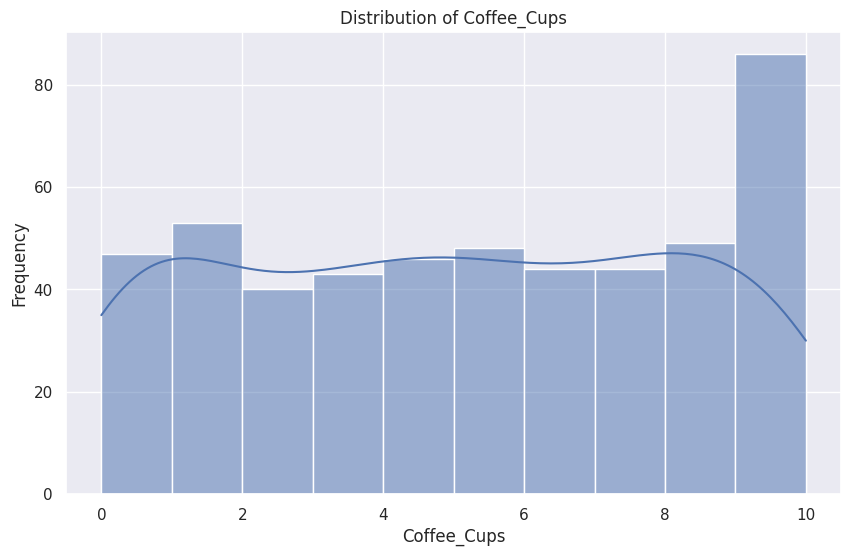

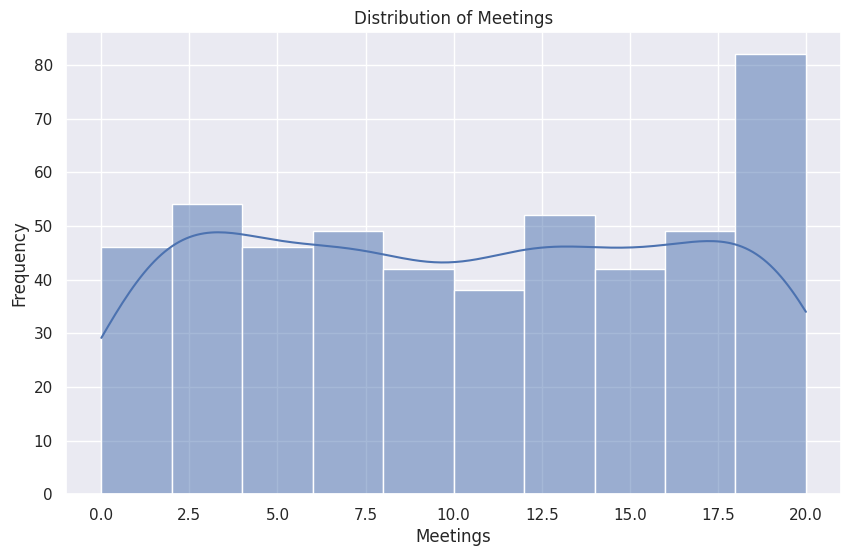

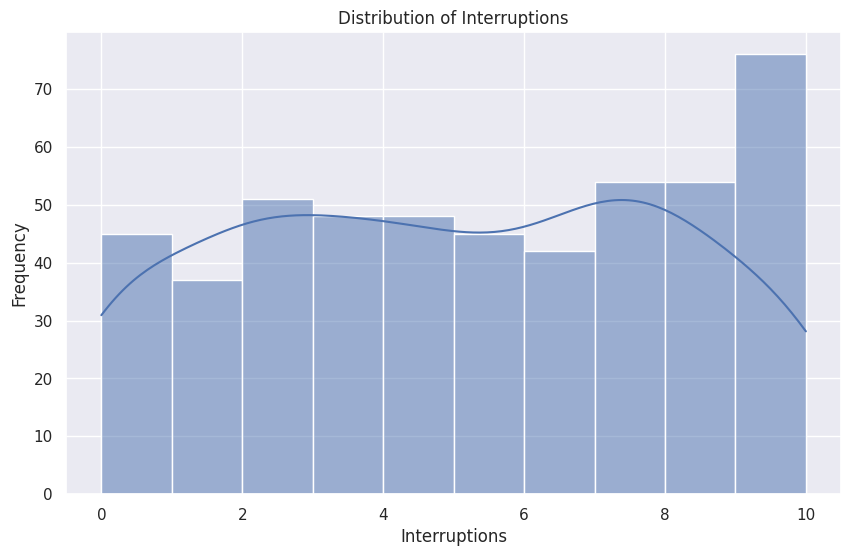

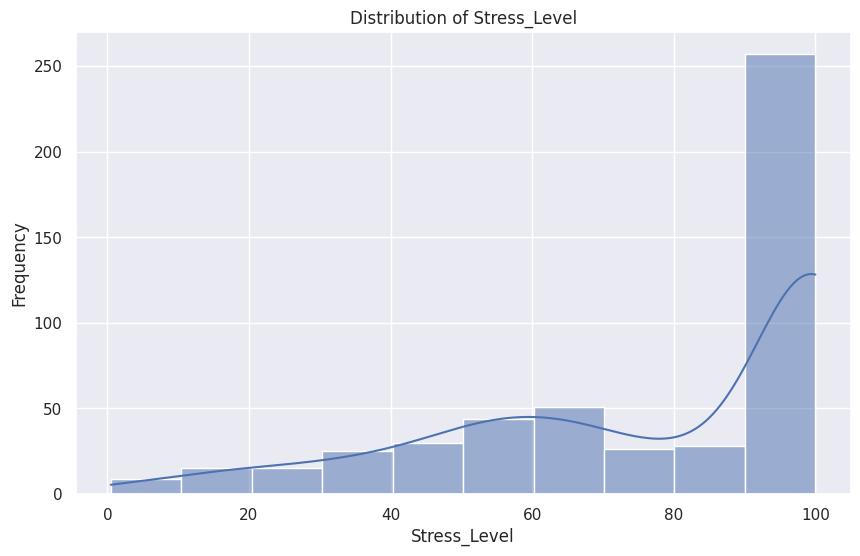

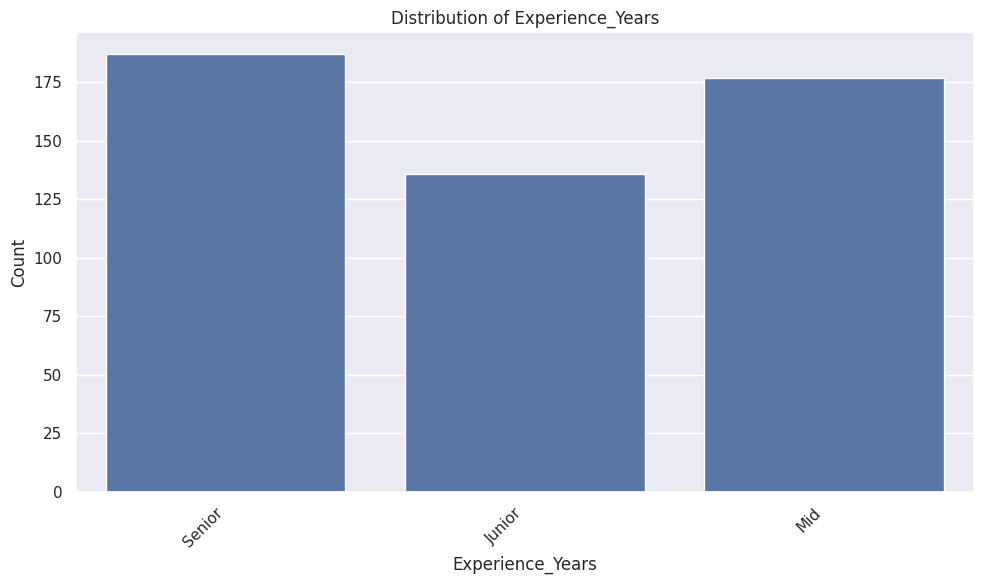

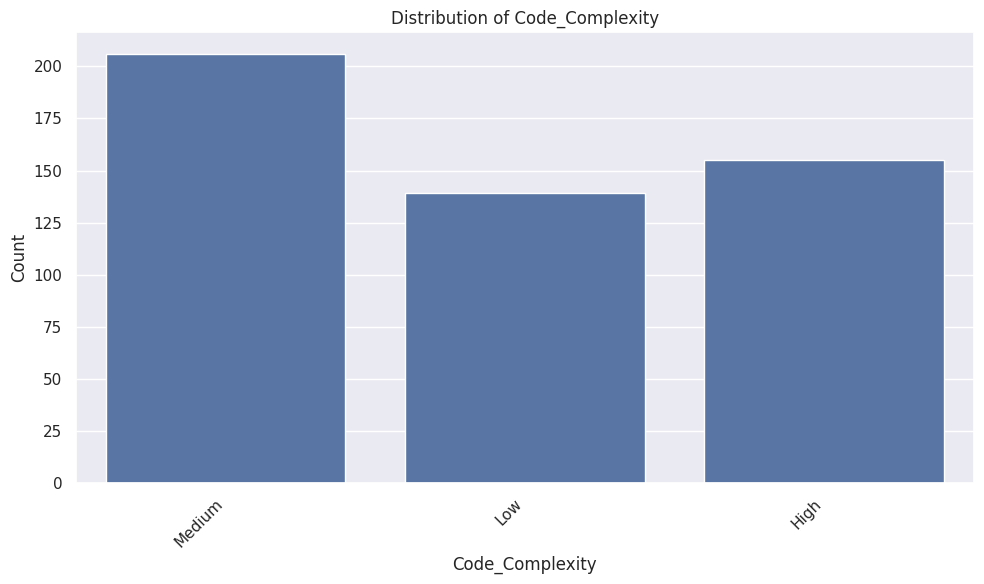

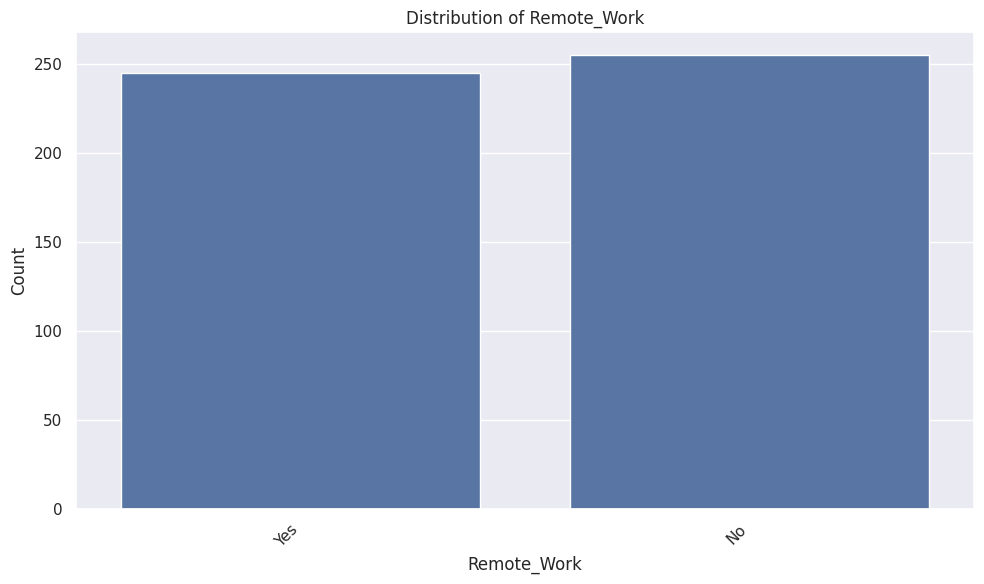

Value counts for Experience_Years:
Experience_Years
Senior    187
Mid       177
Junior    136
Name: count, dtype: int64

Value counts for Code_Complexity:
Code_Complexity
Medium    206
High      155
Low       139
Name: count, dtype: int64

Value counts for Remote_Work:
Remote_Work
No     255
Yes    245
Name: count, dtype: int64



In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

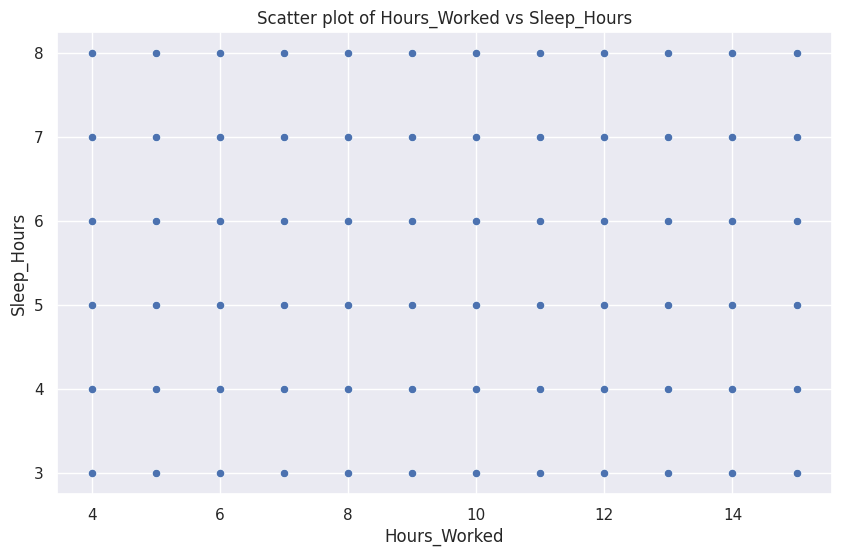

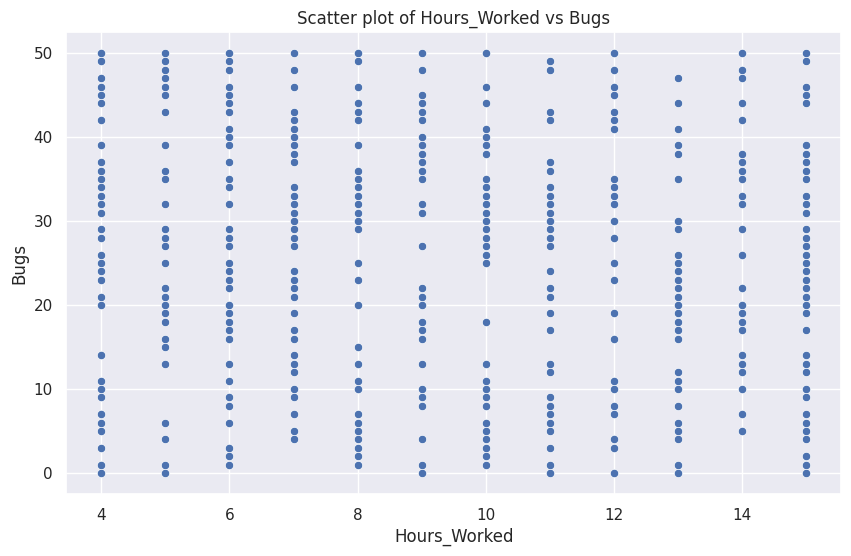

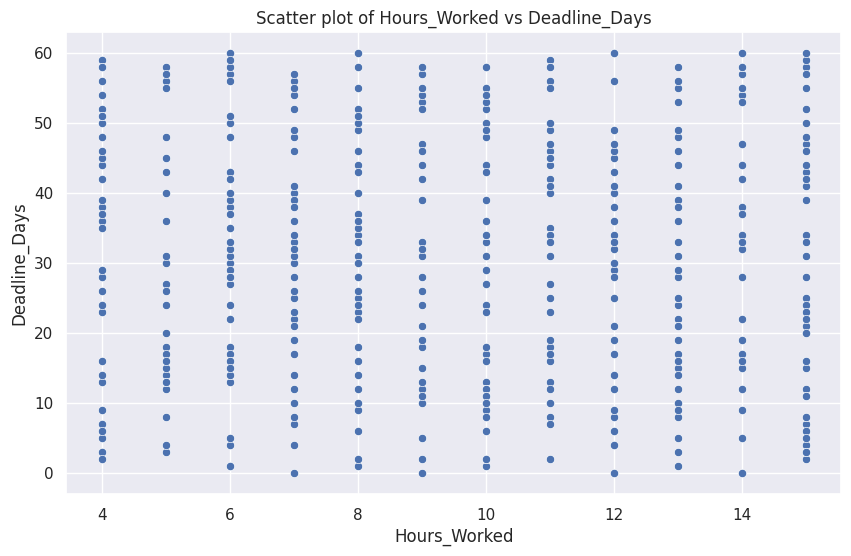

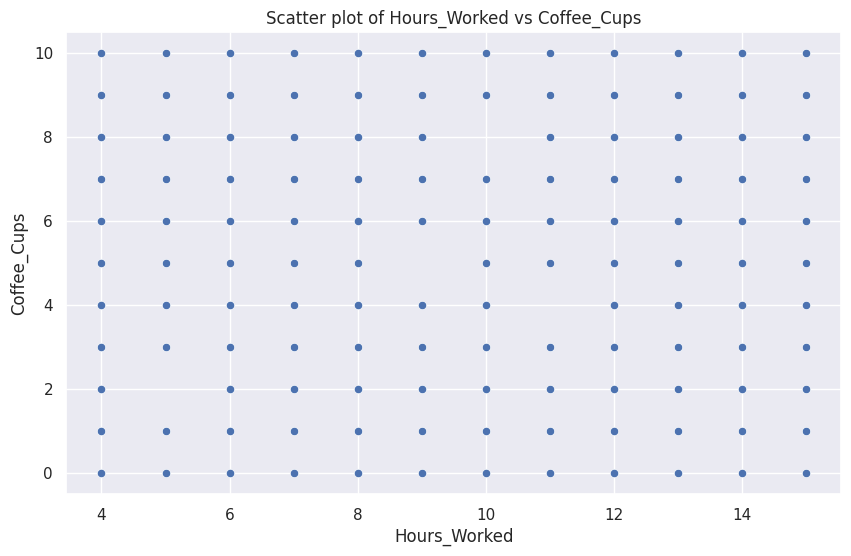

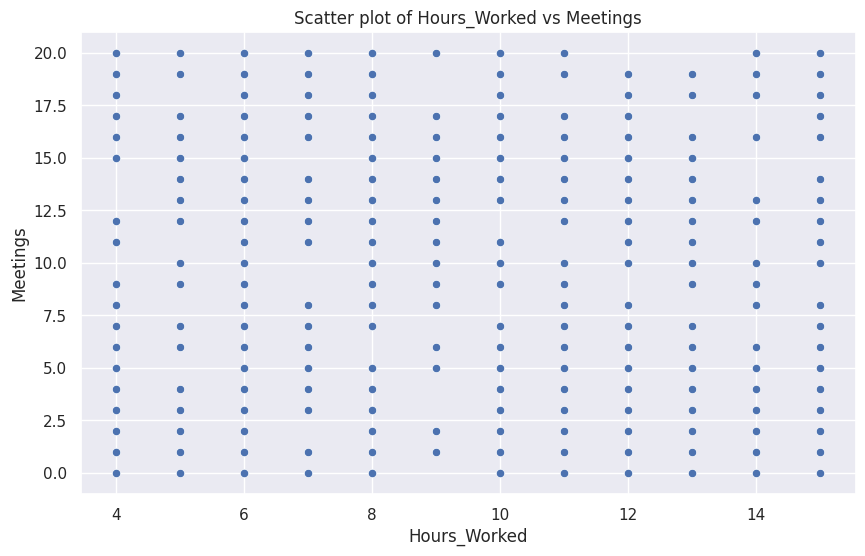

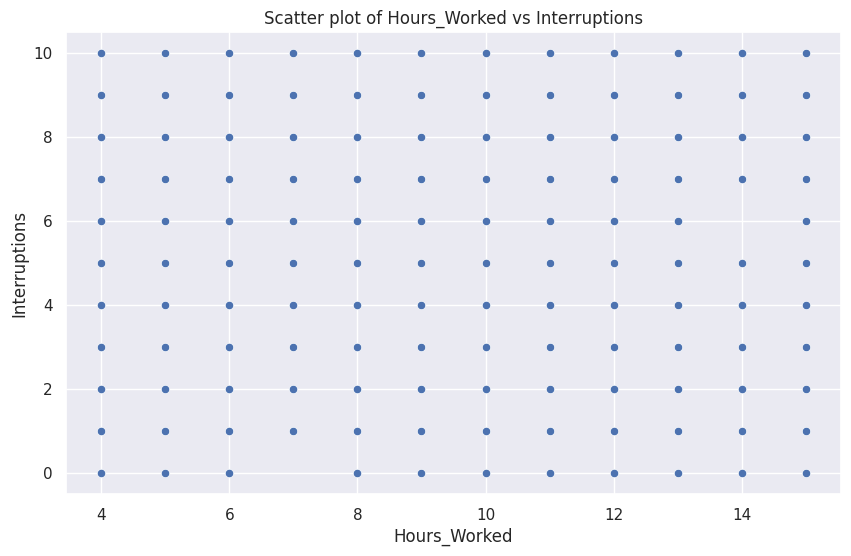

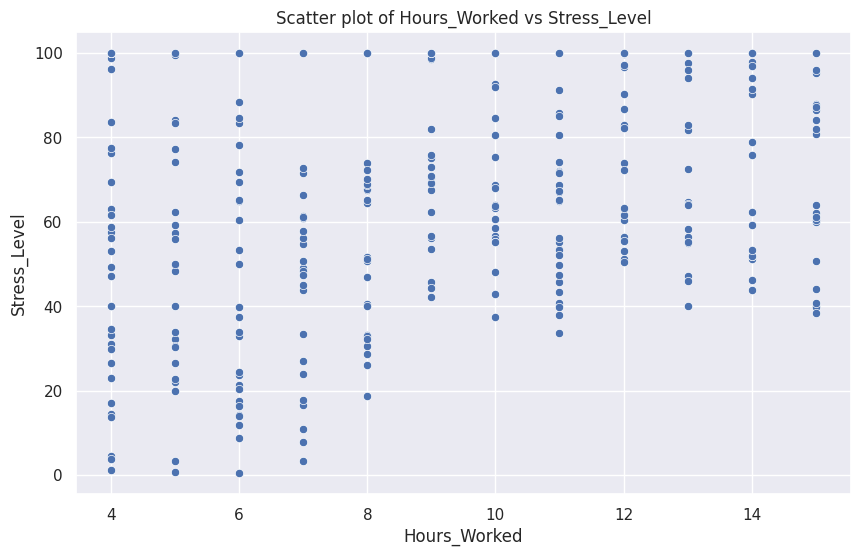

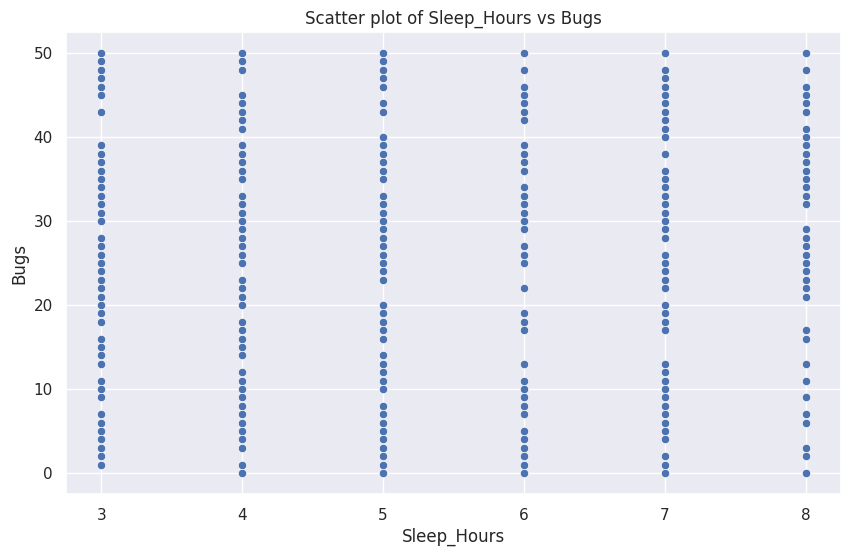

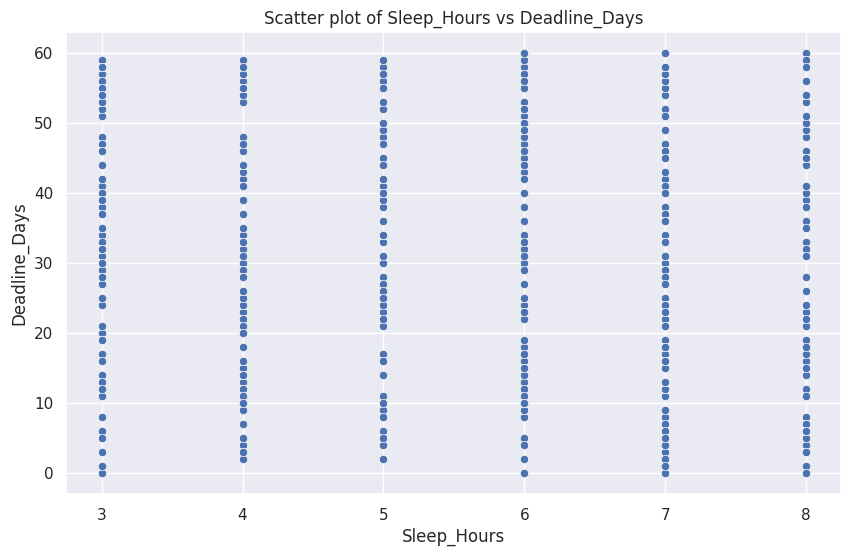

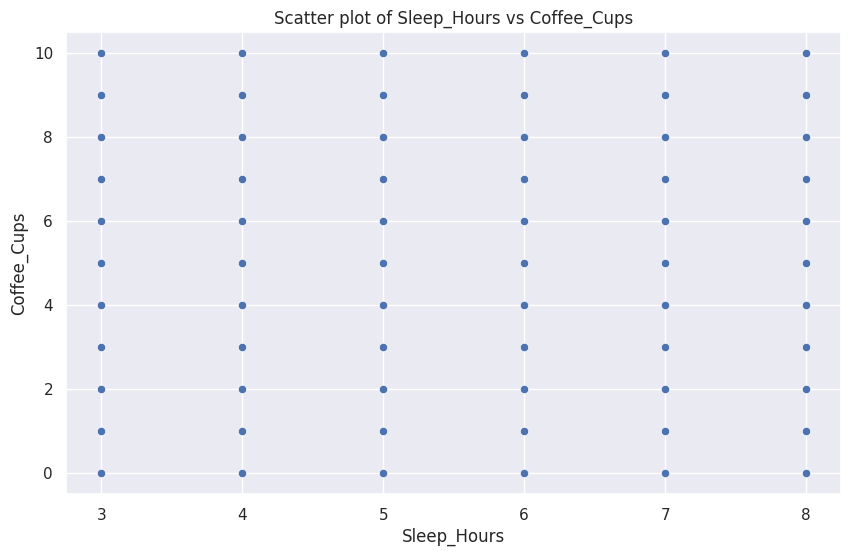

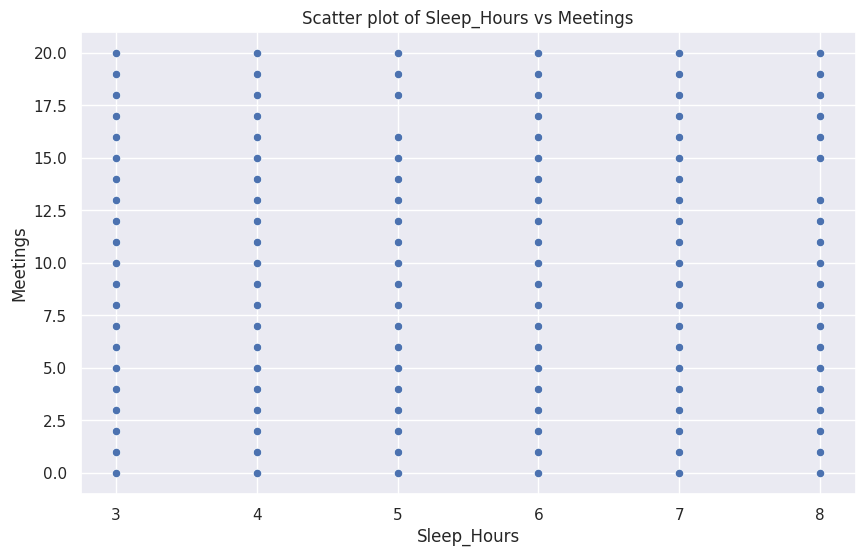

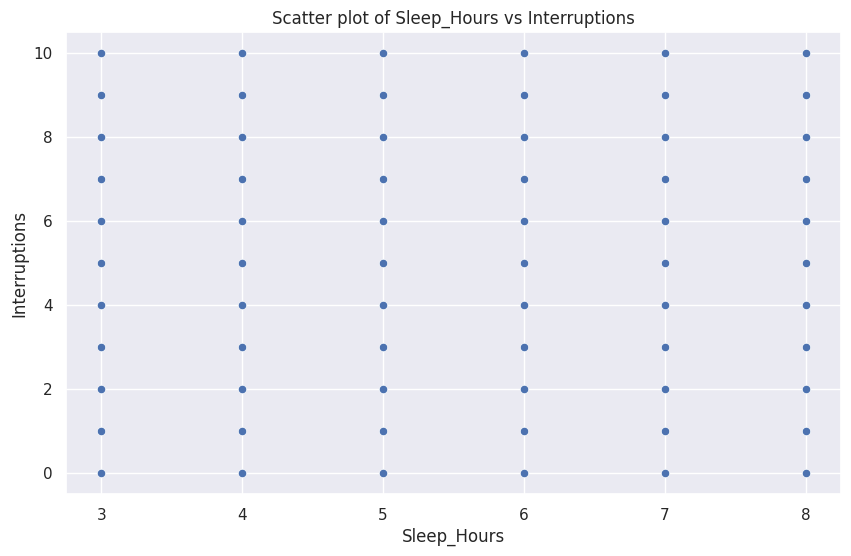

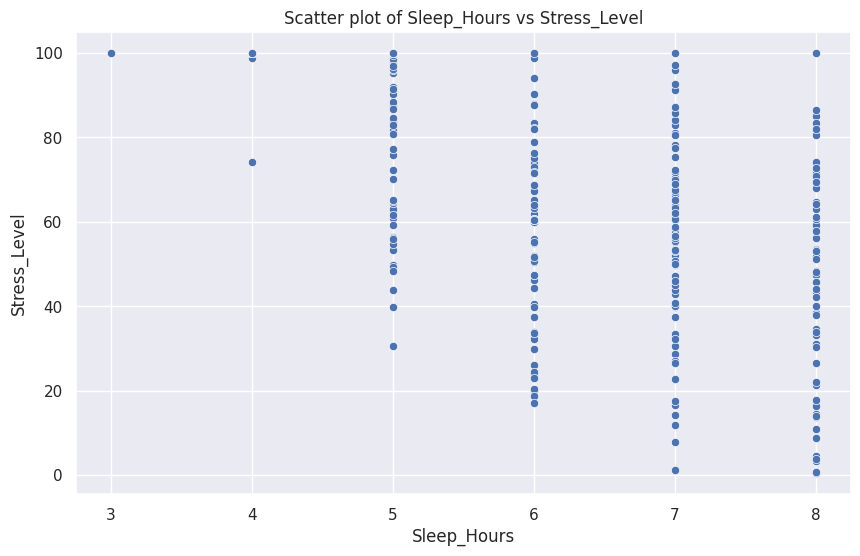

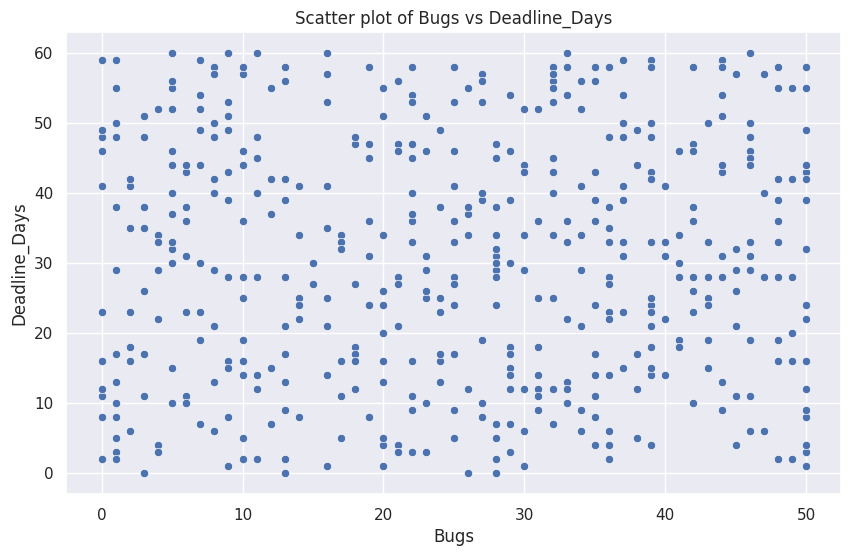

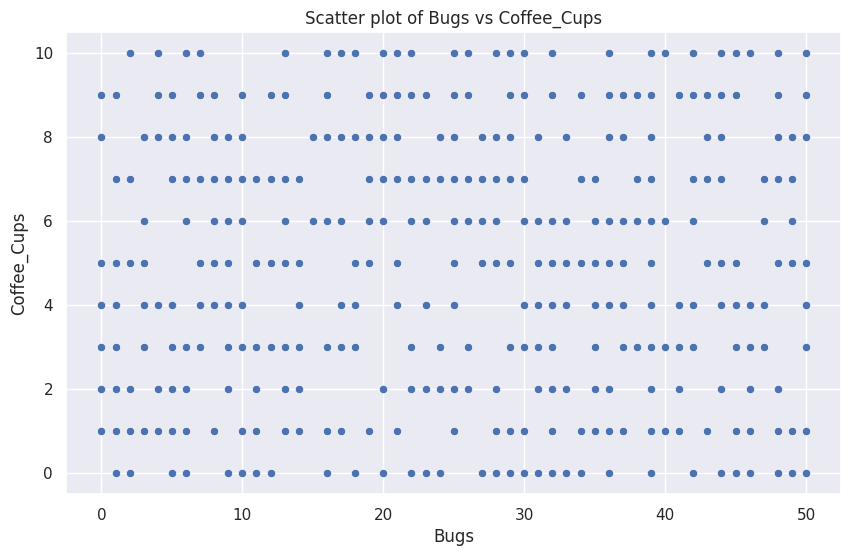

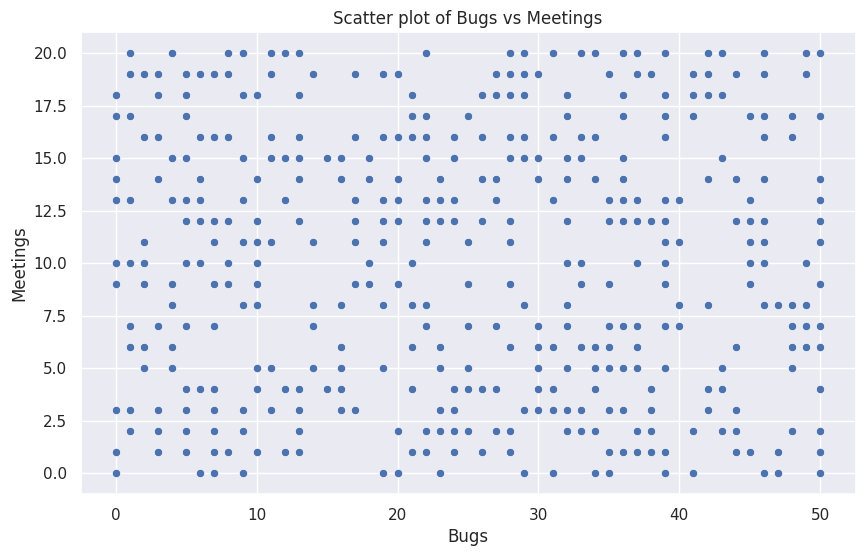

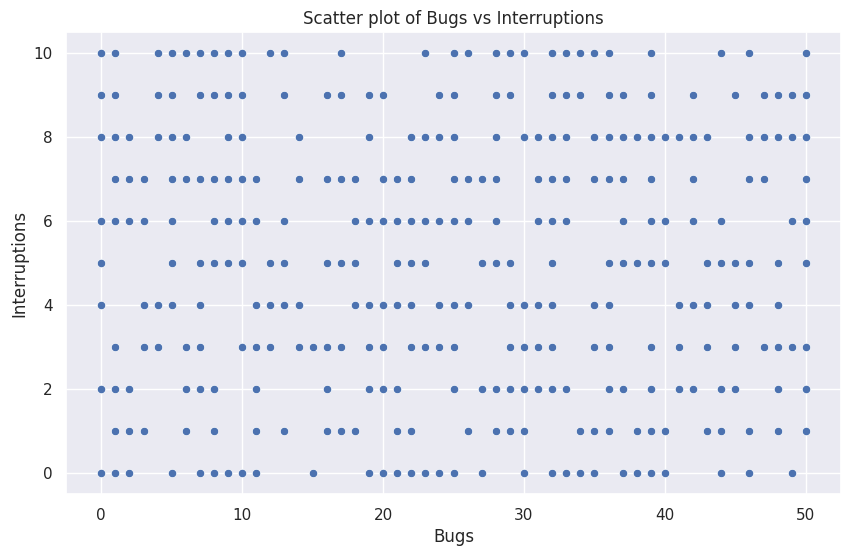

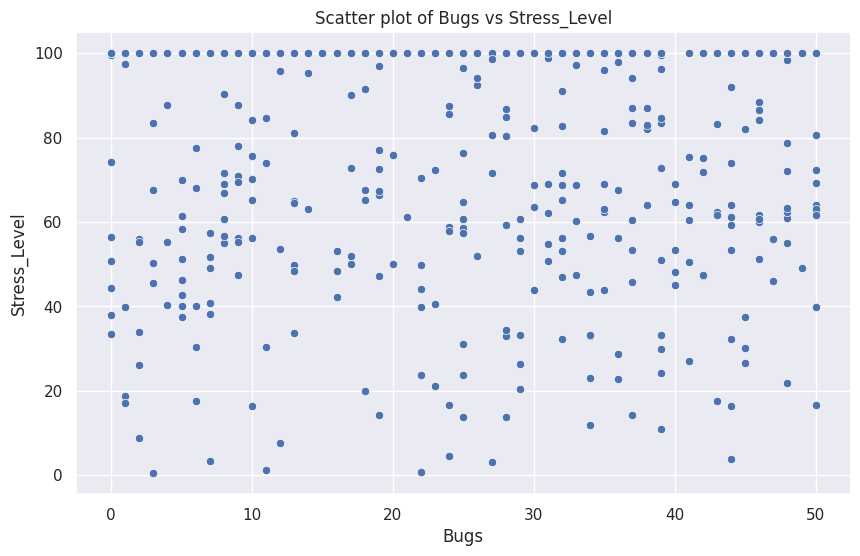

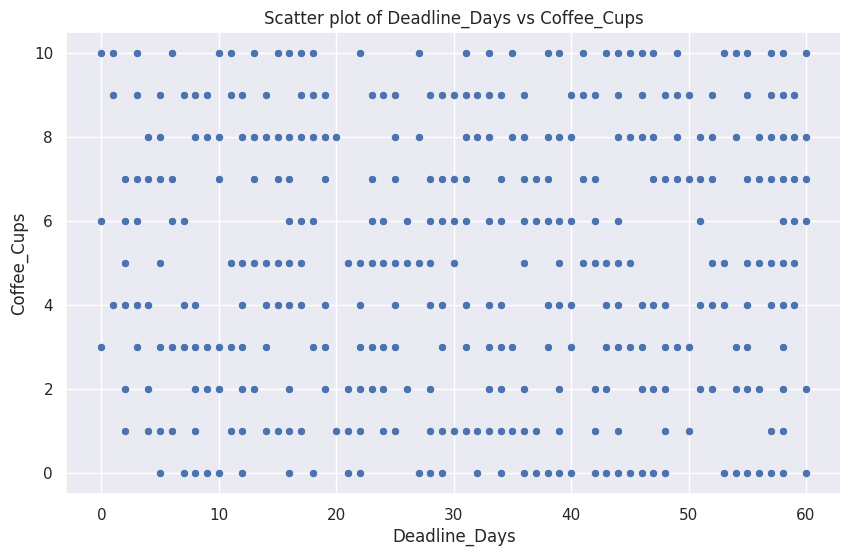

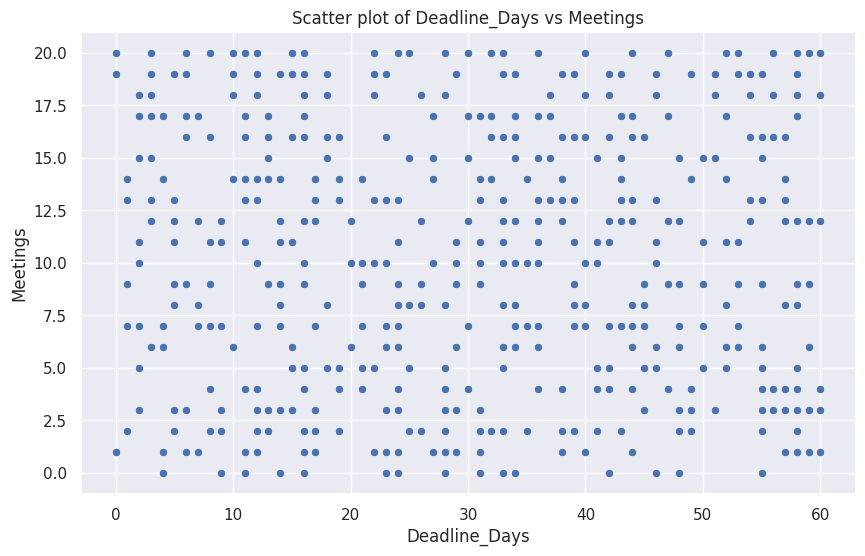

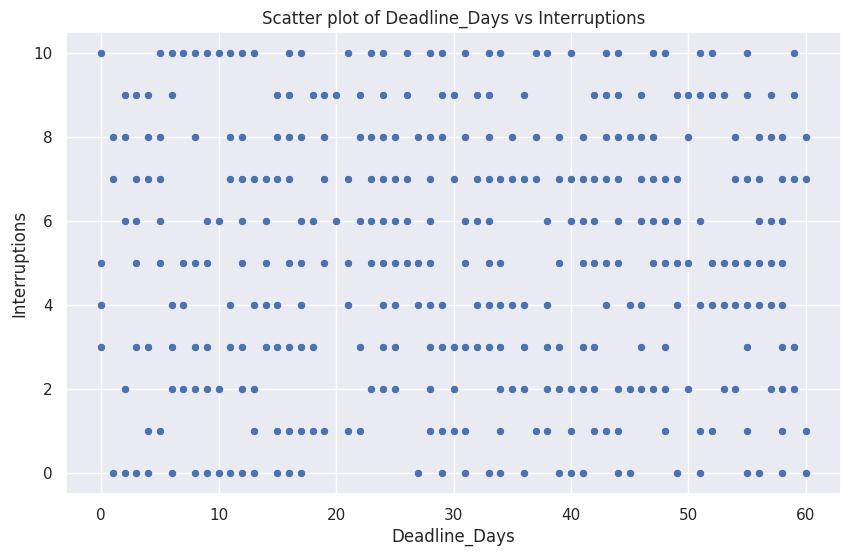

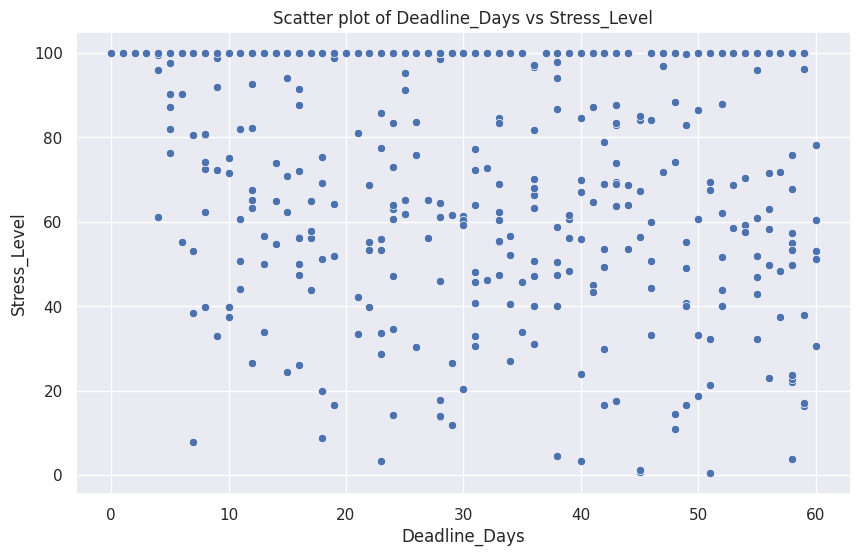

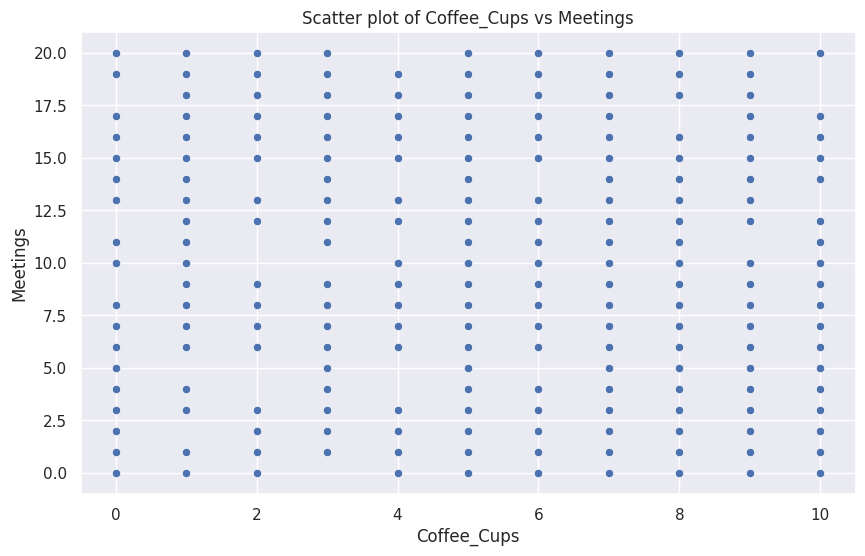

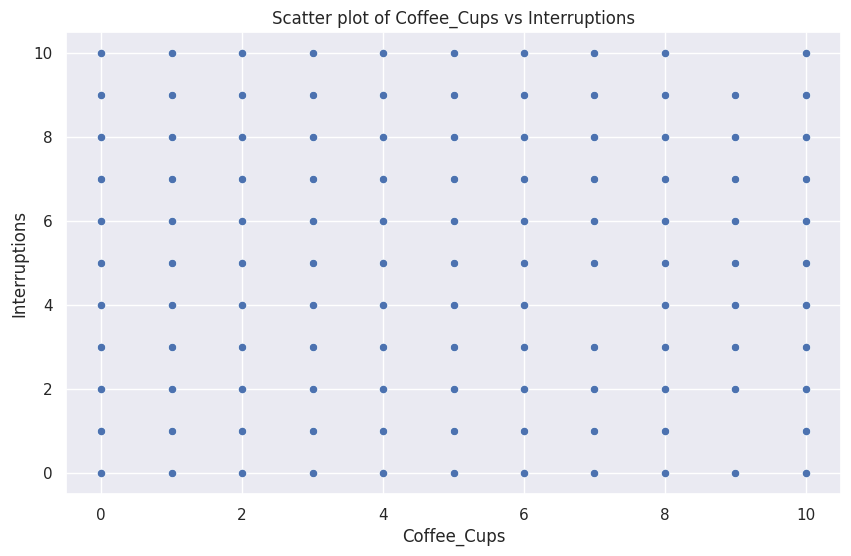

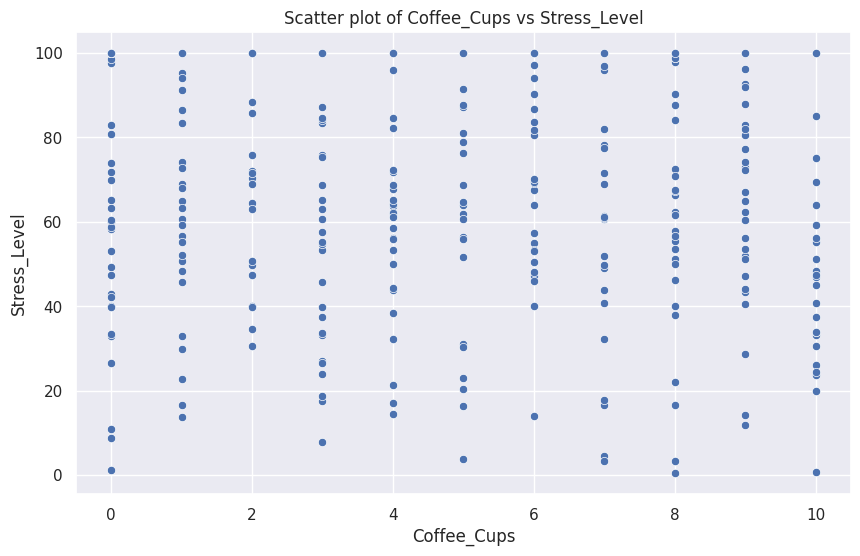

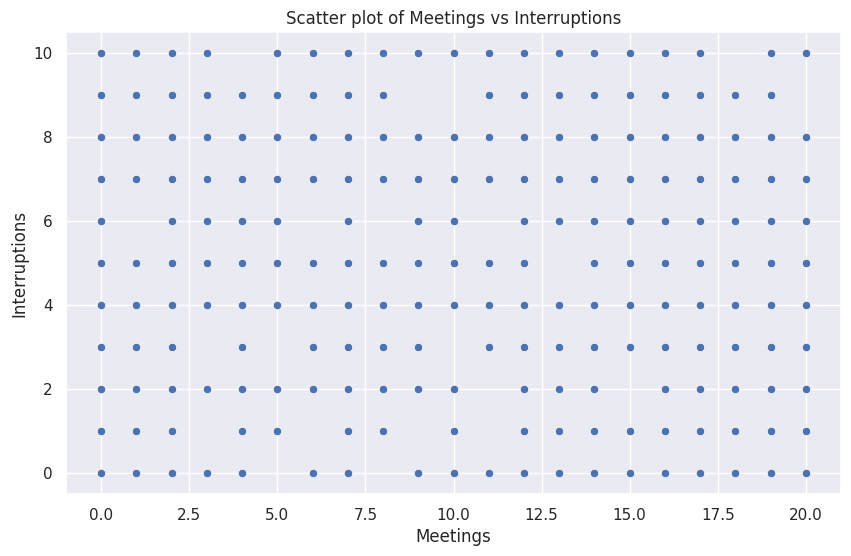

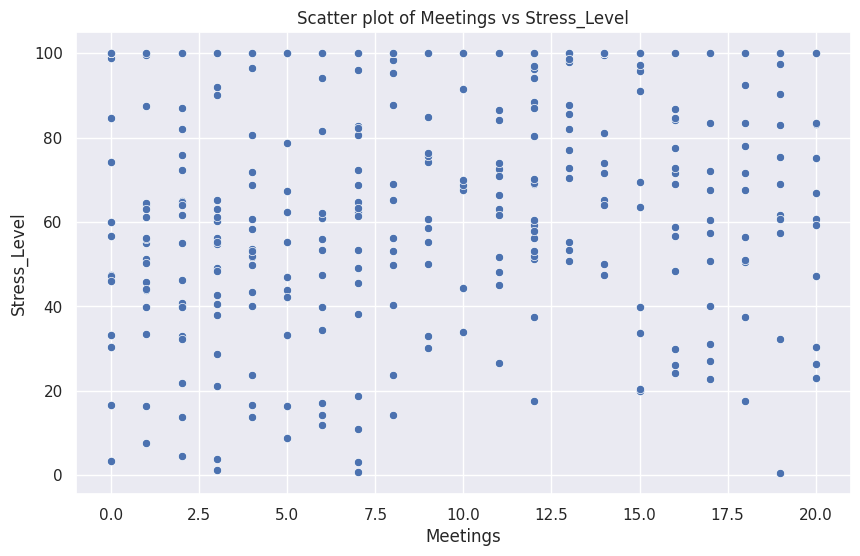

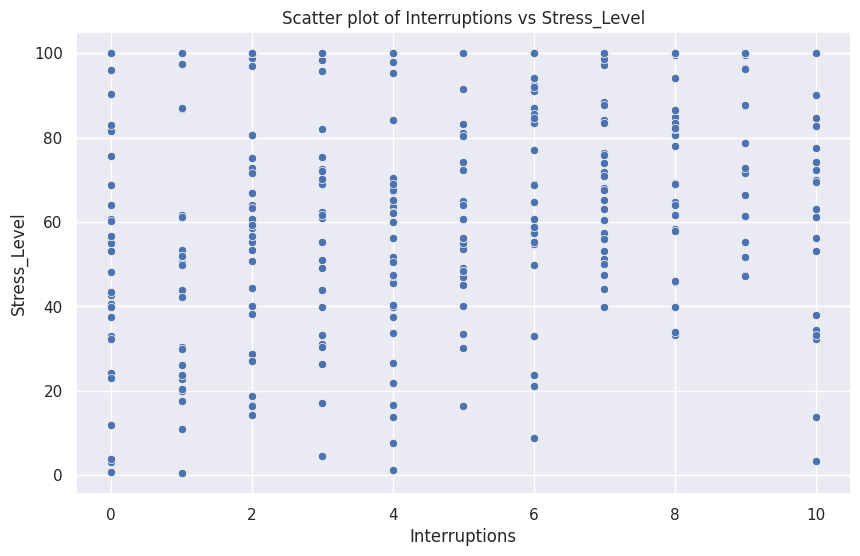

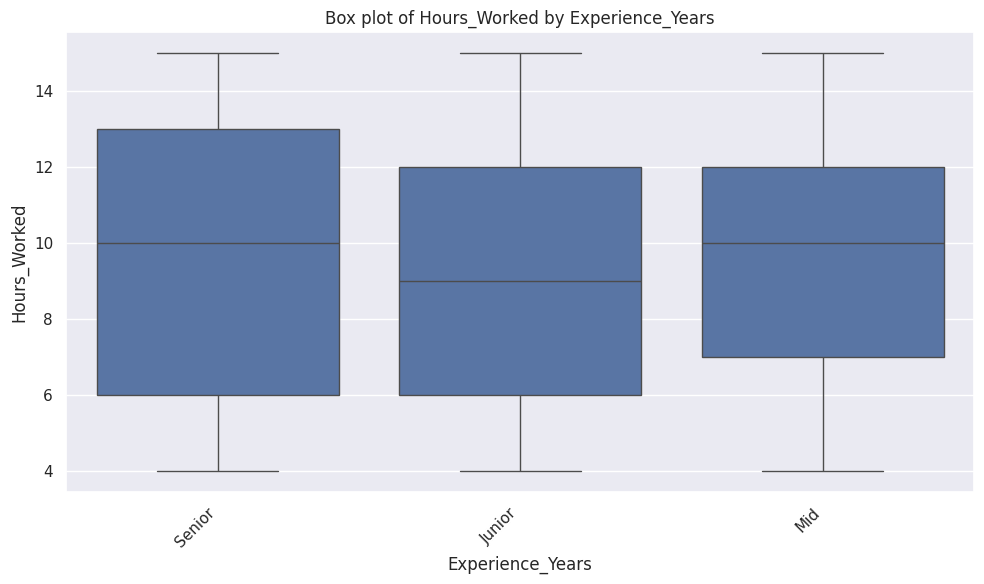

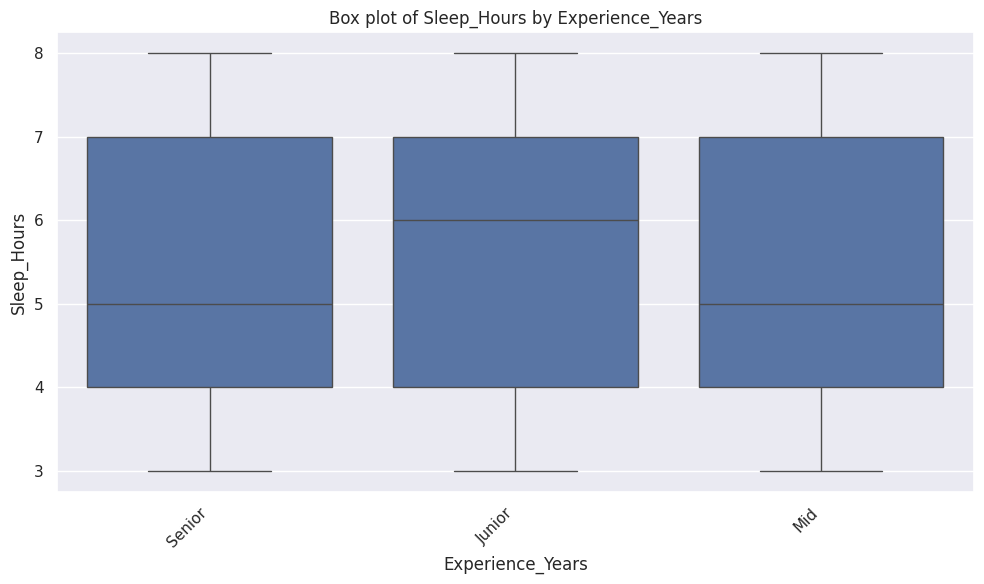

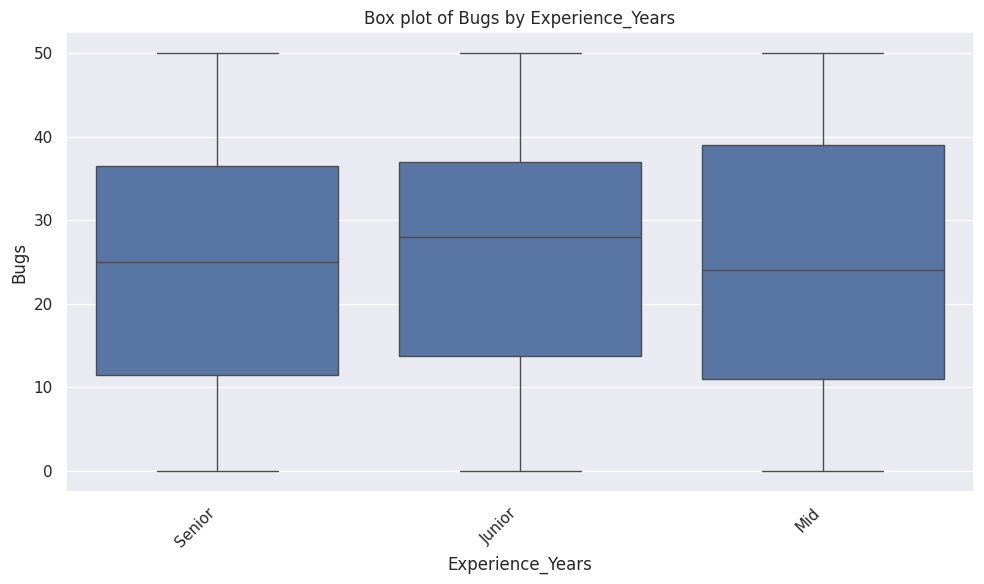

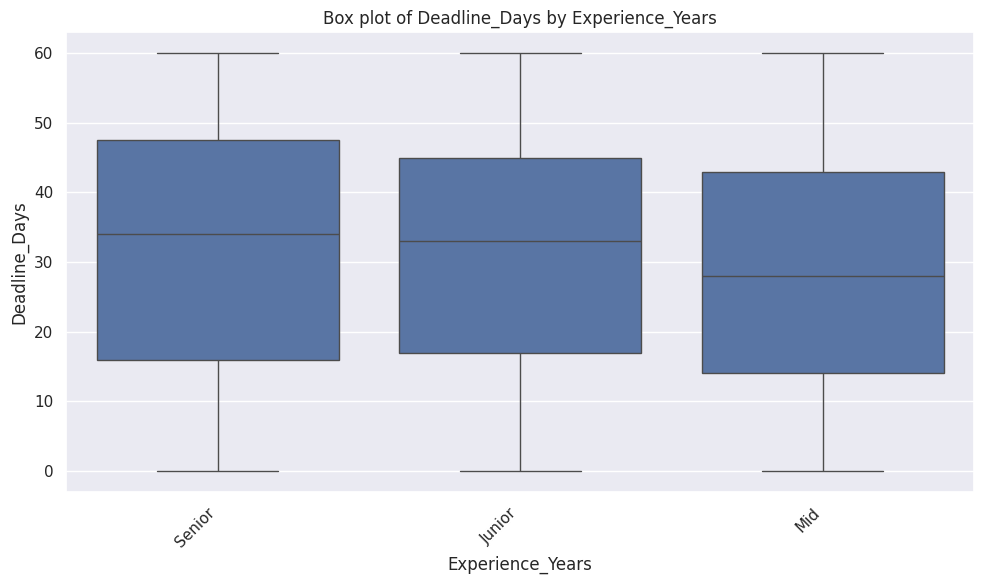

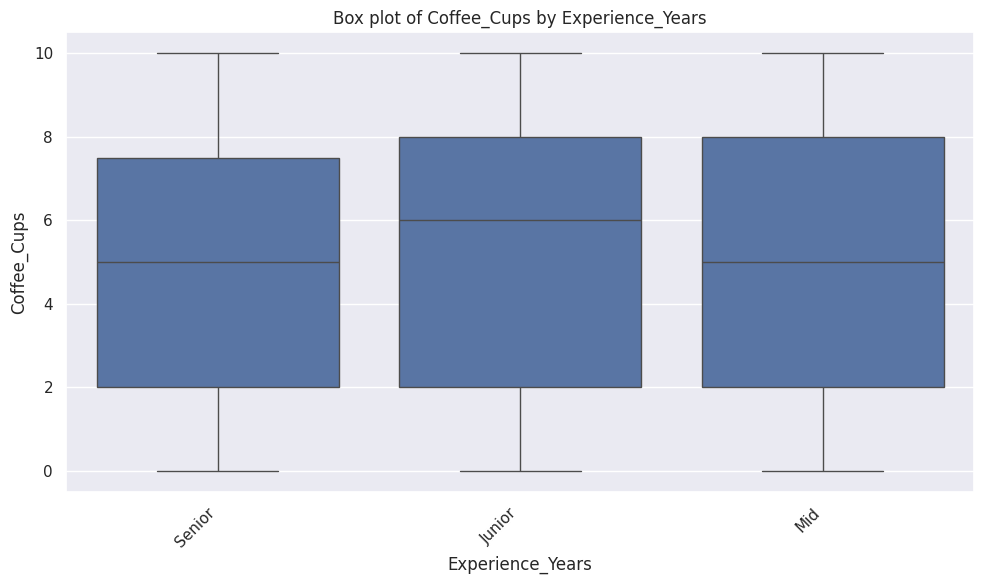

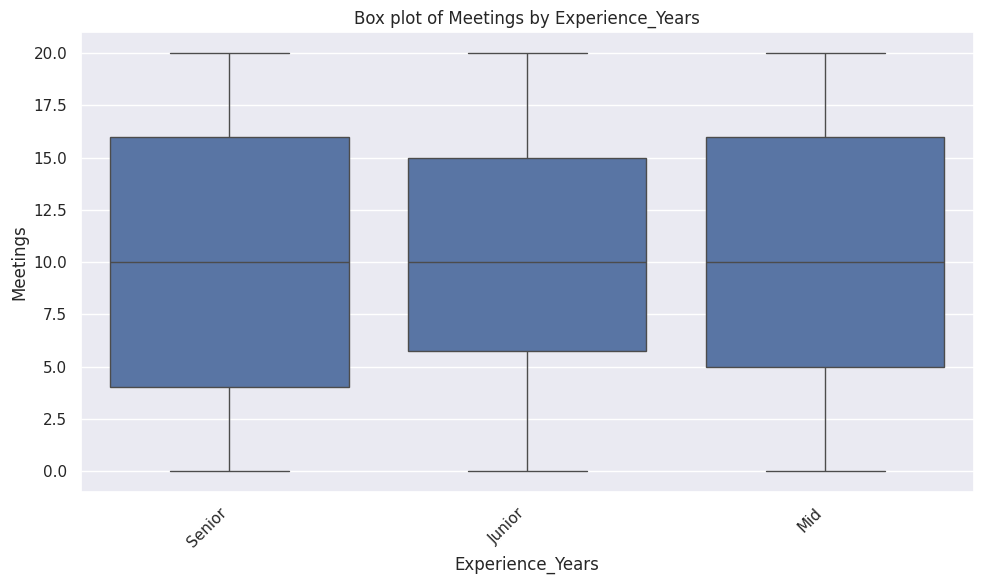

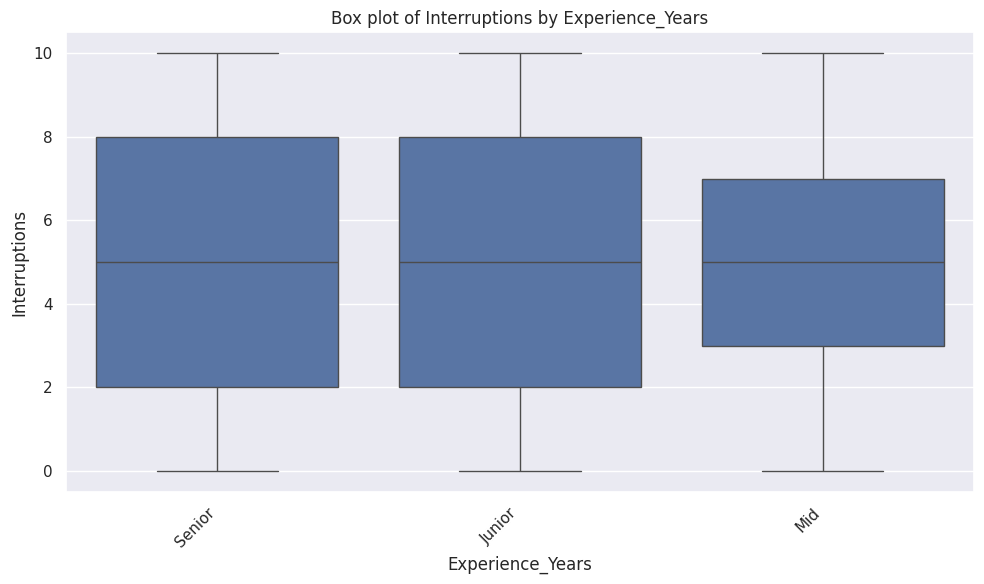

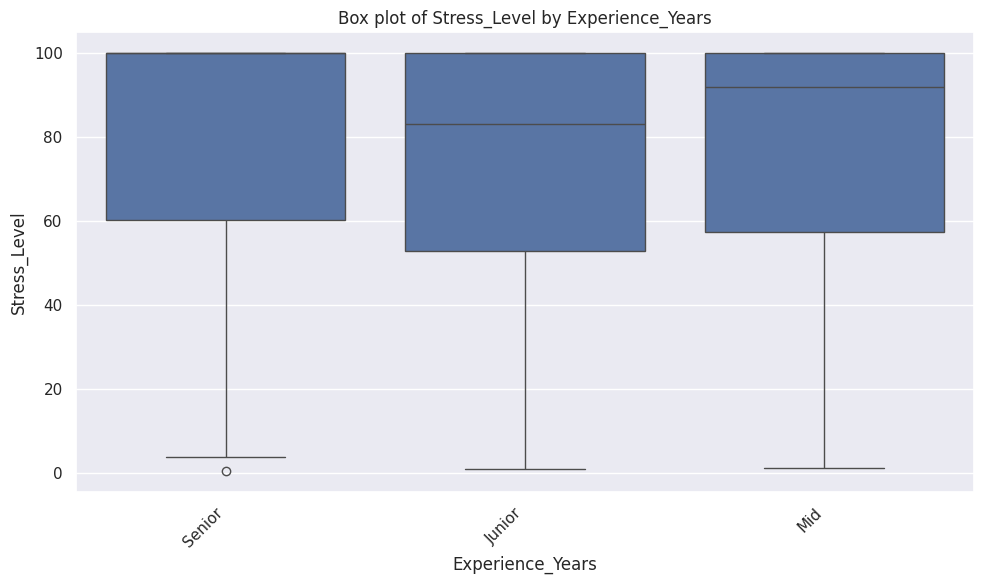

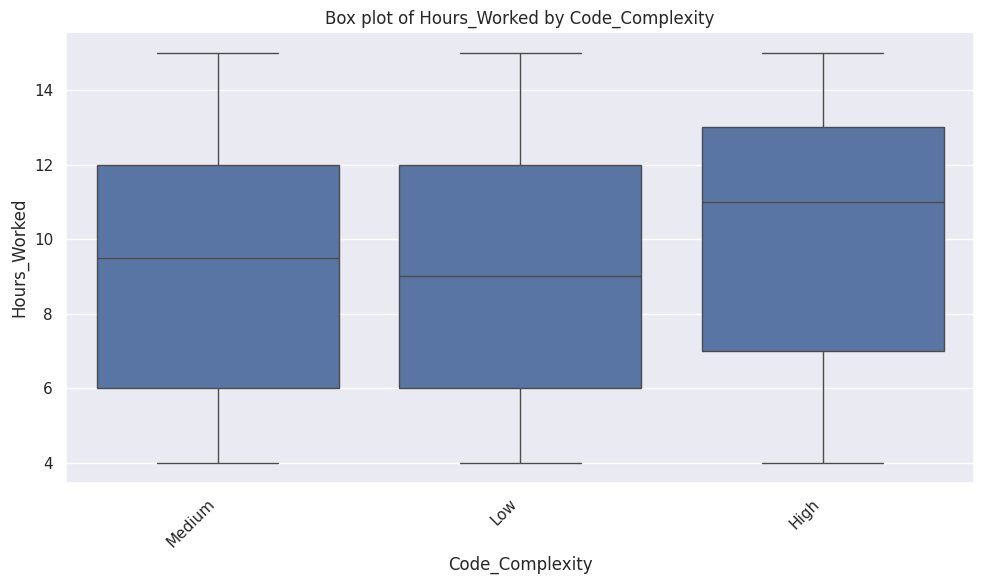

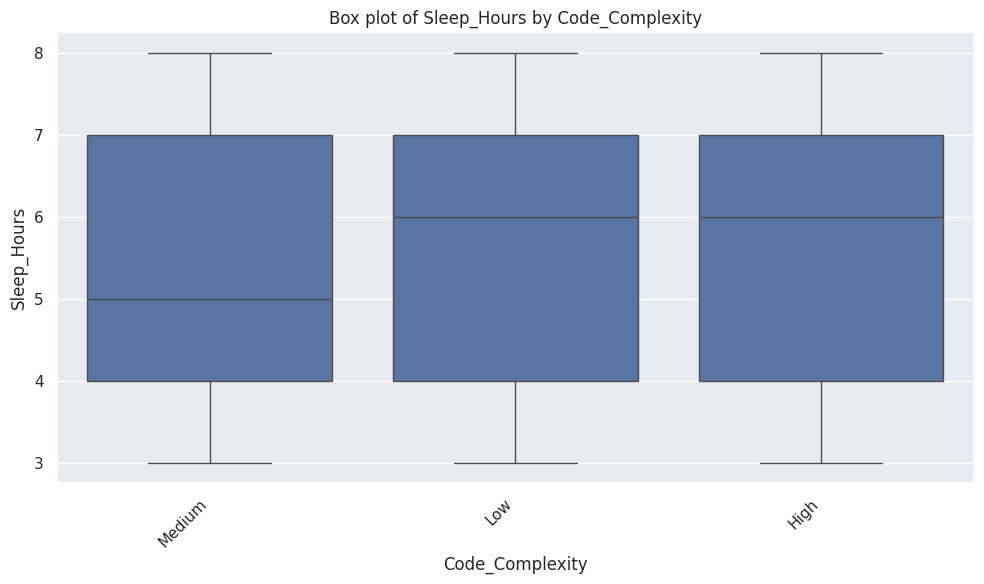

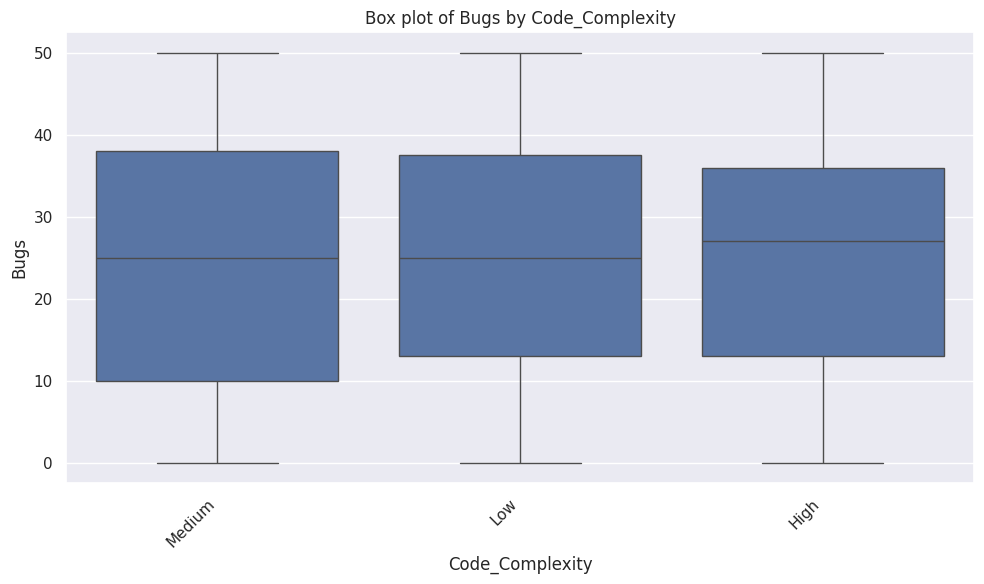

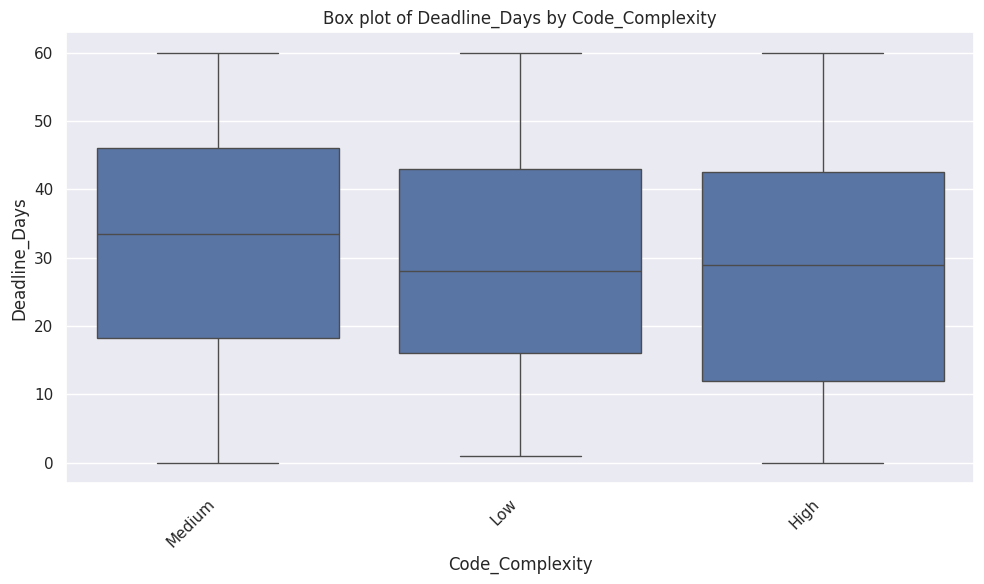

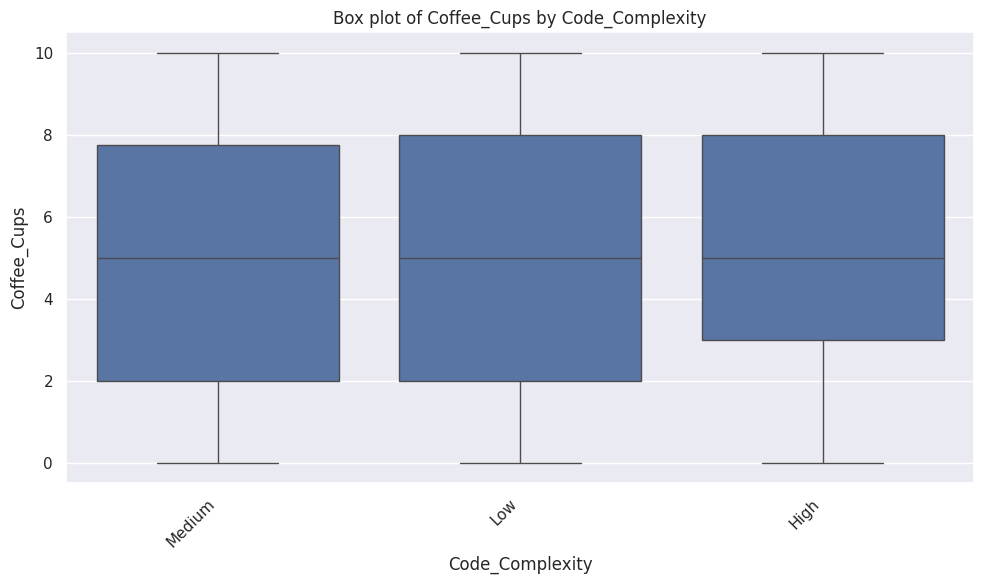

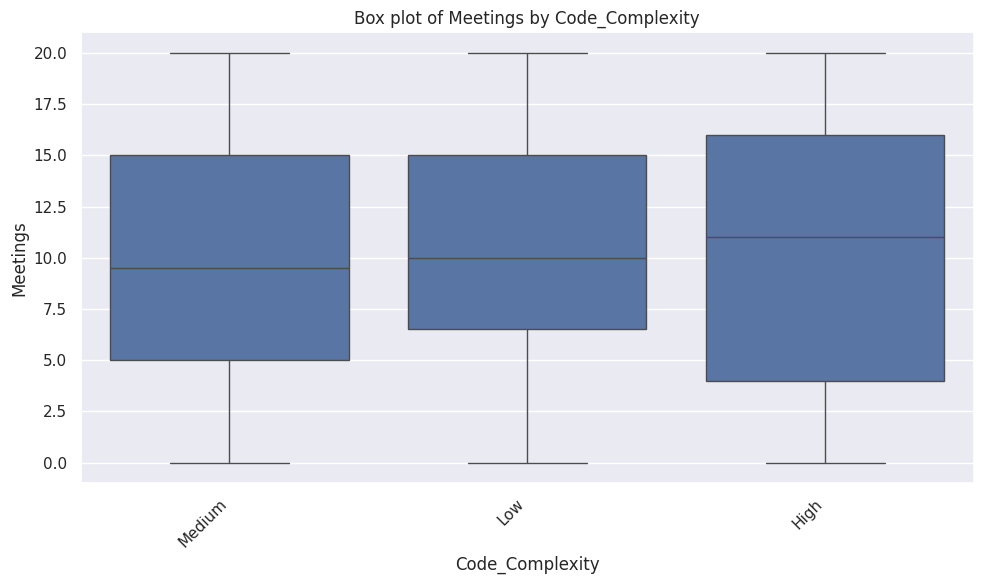

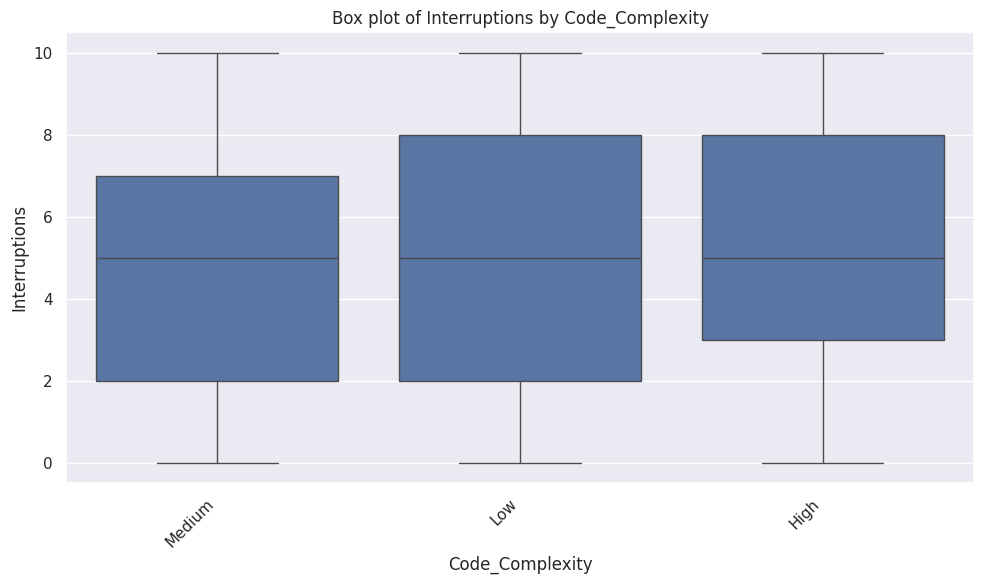

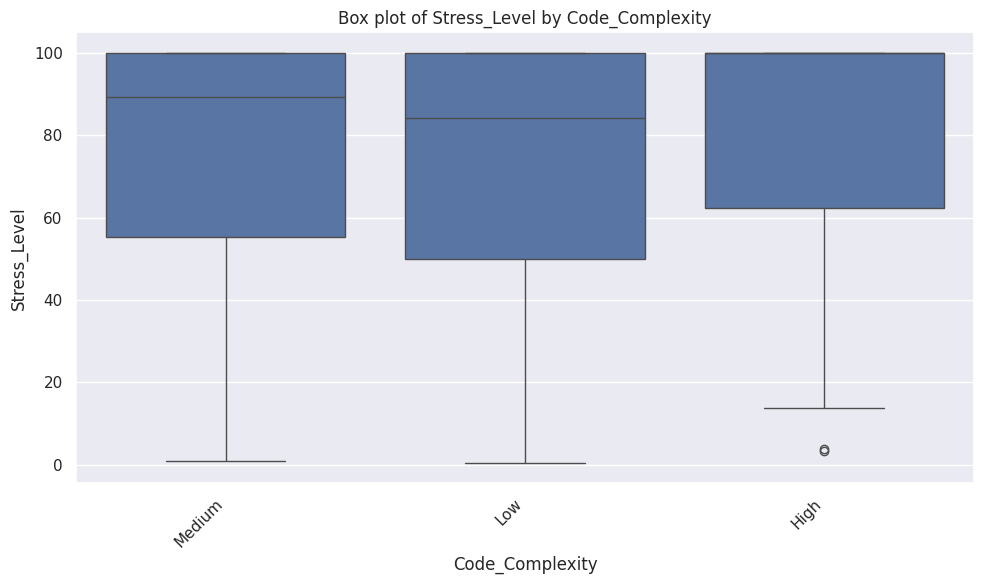

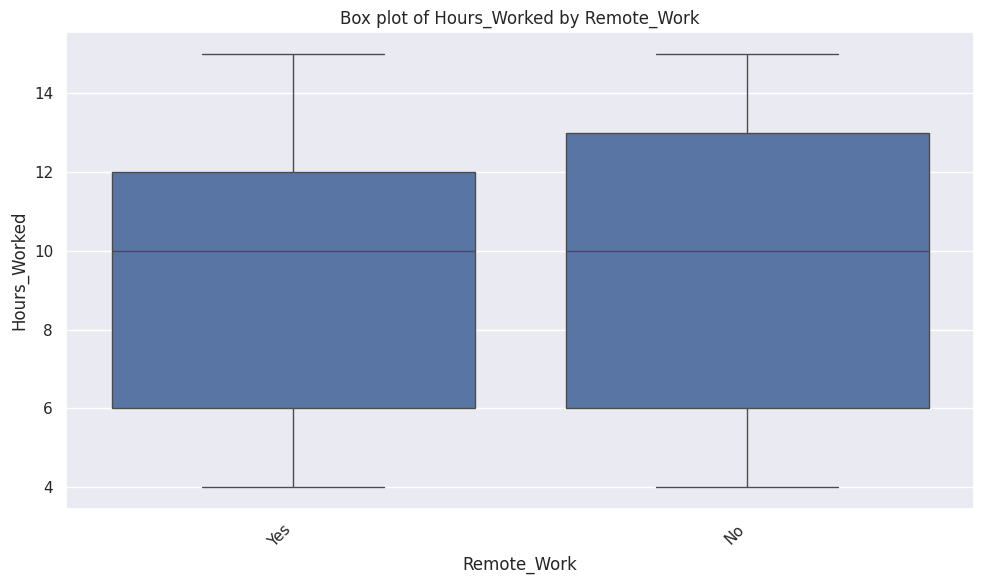

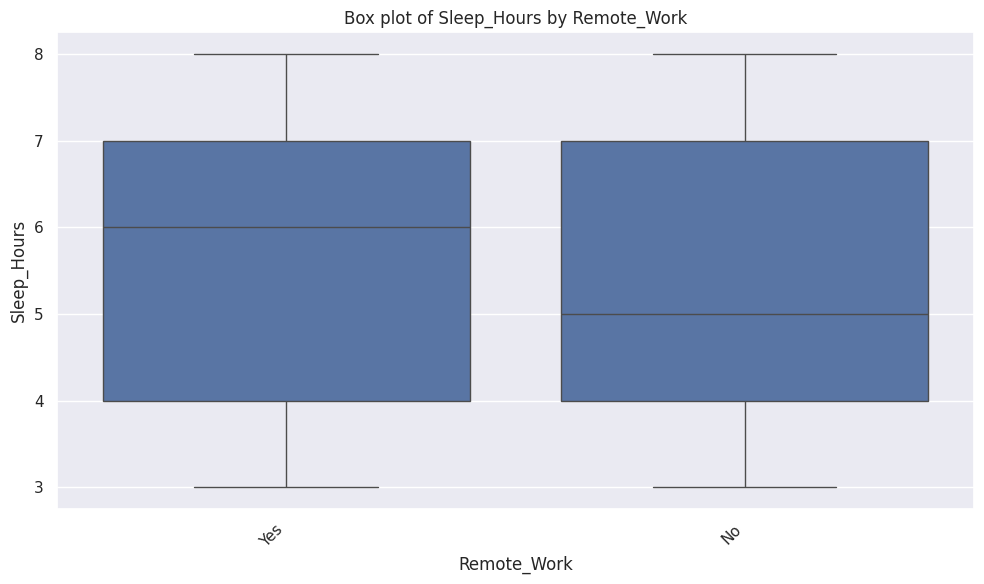

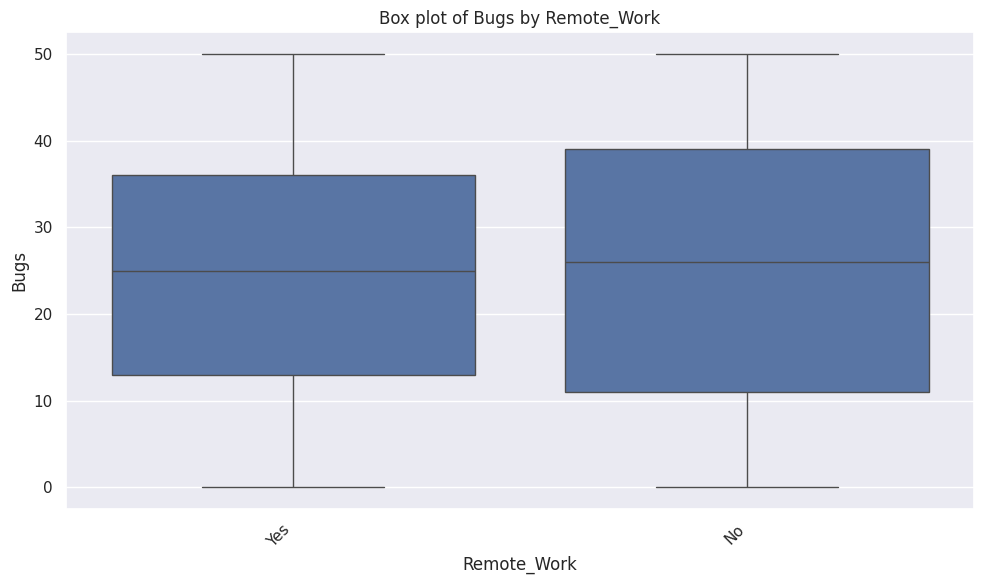

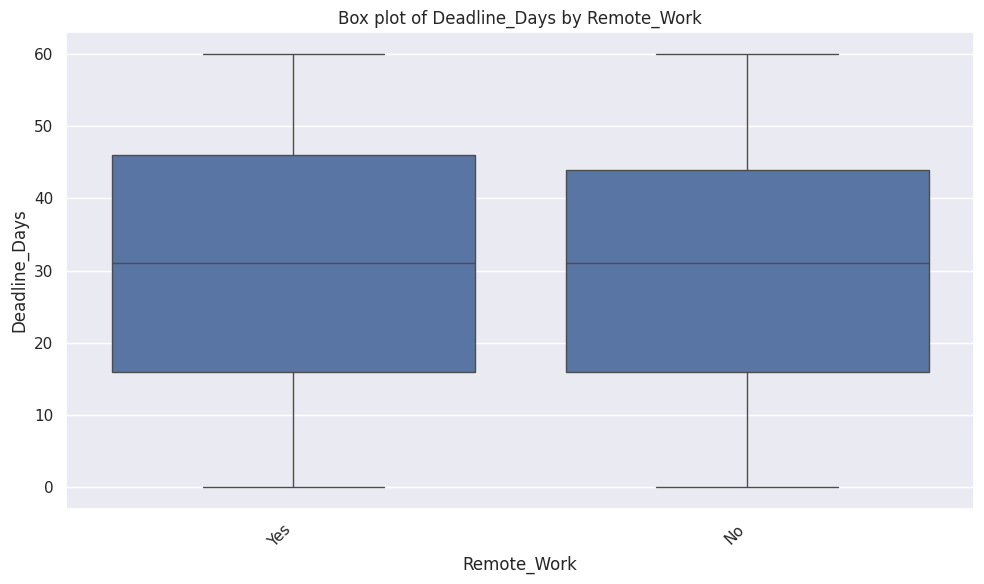

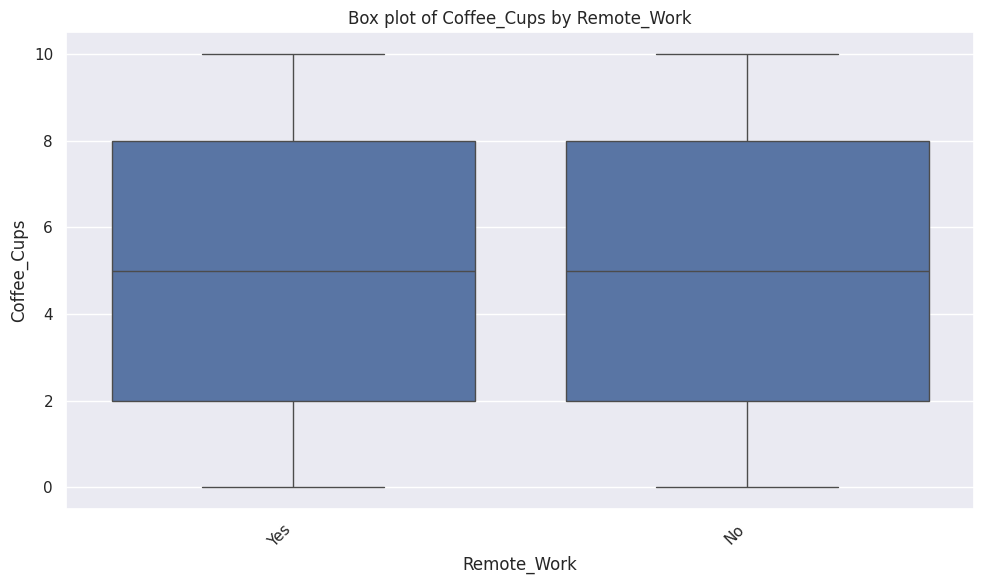

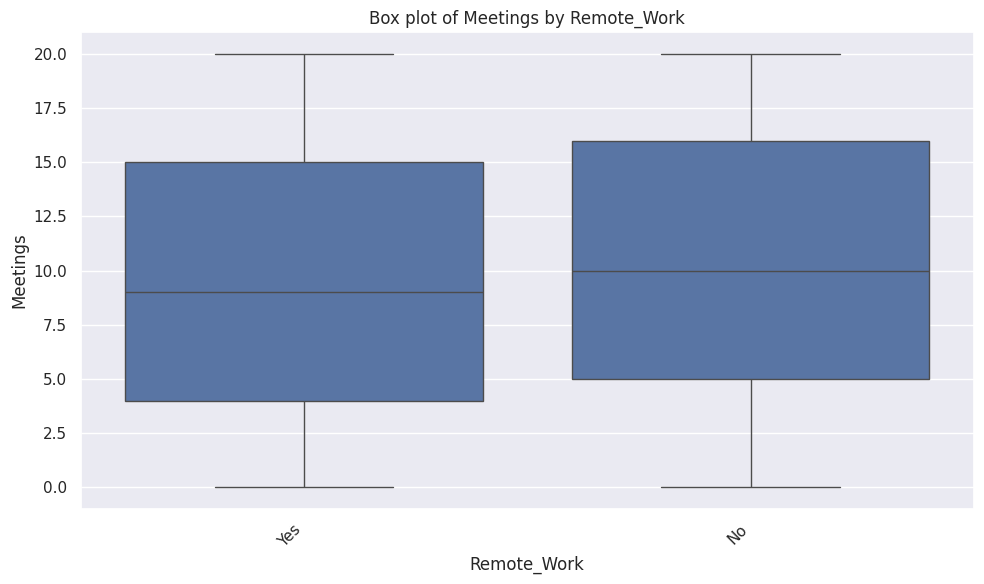

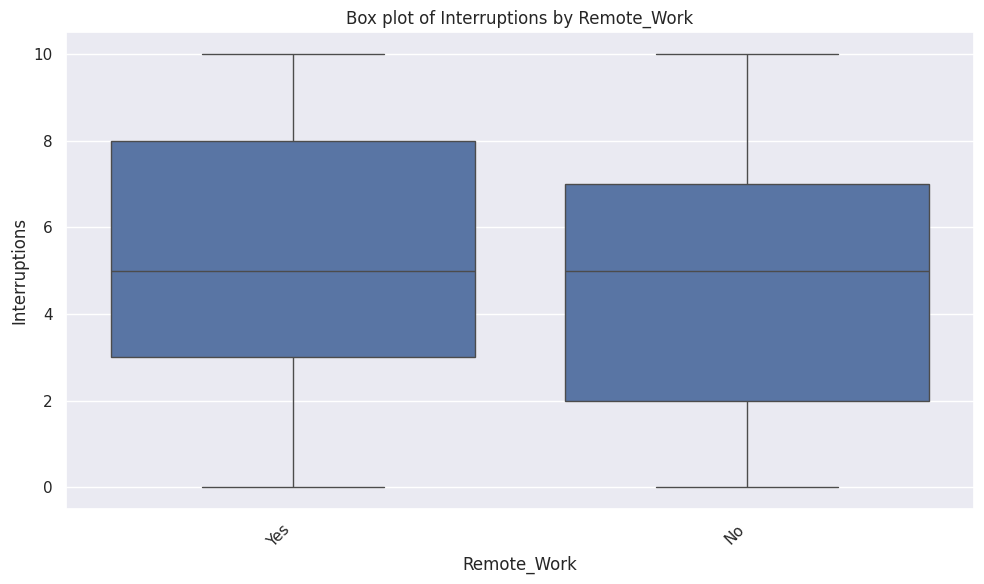

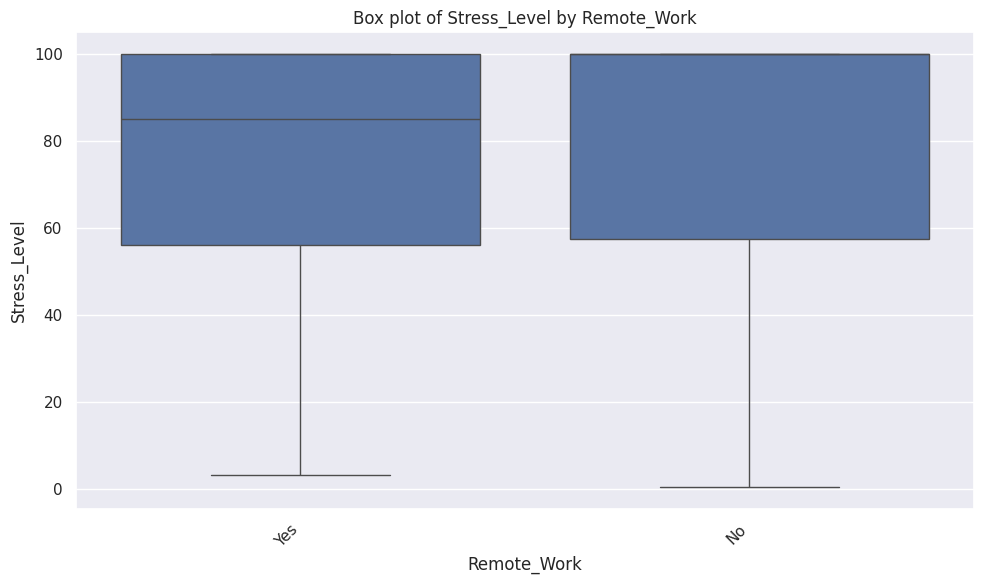

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

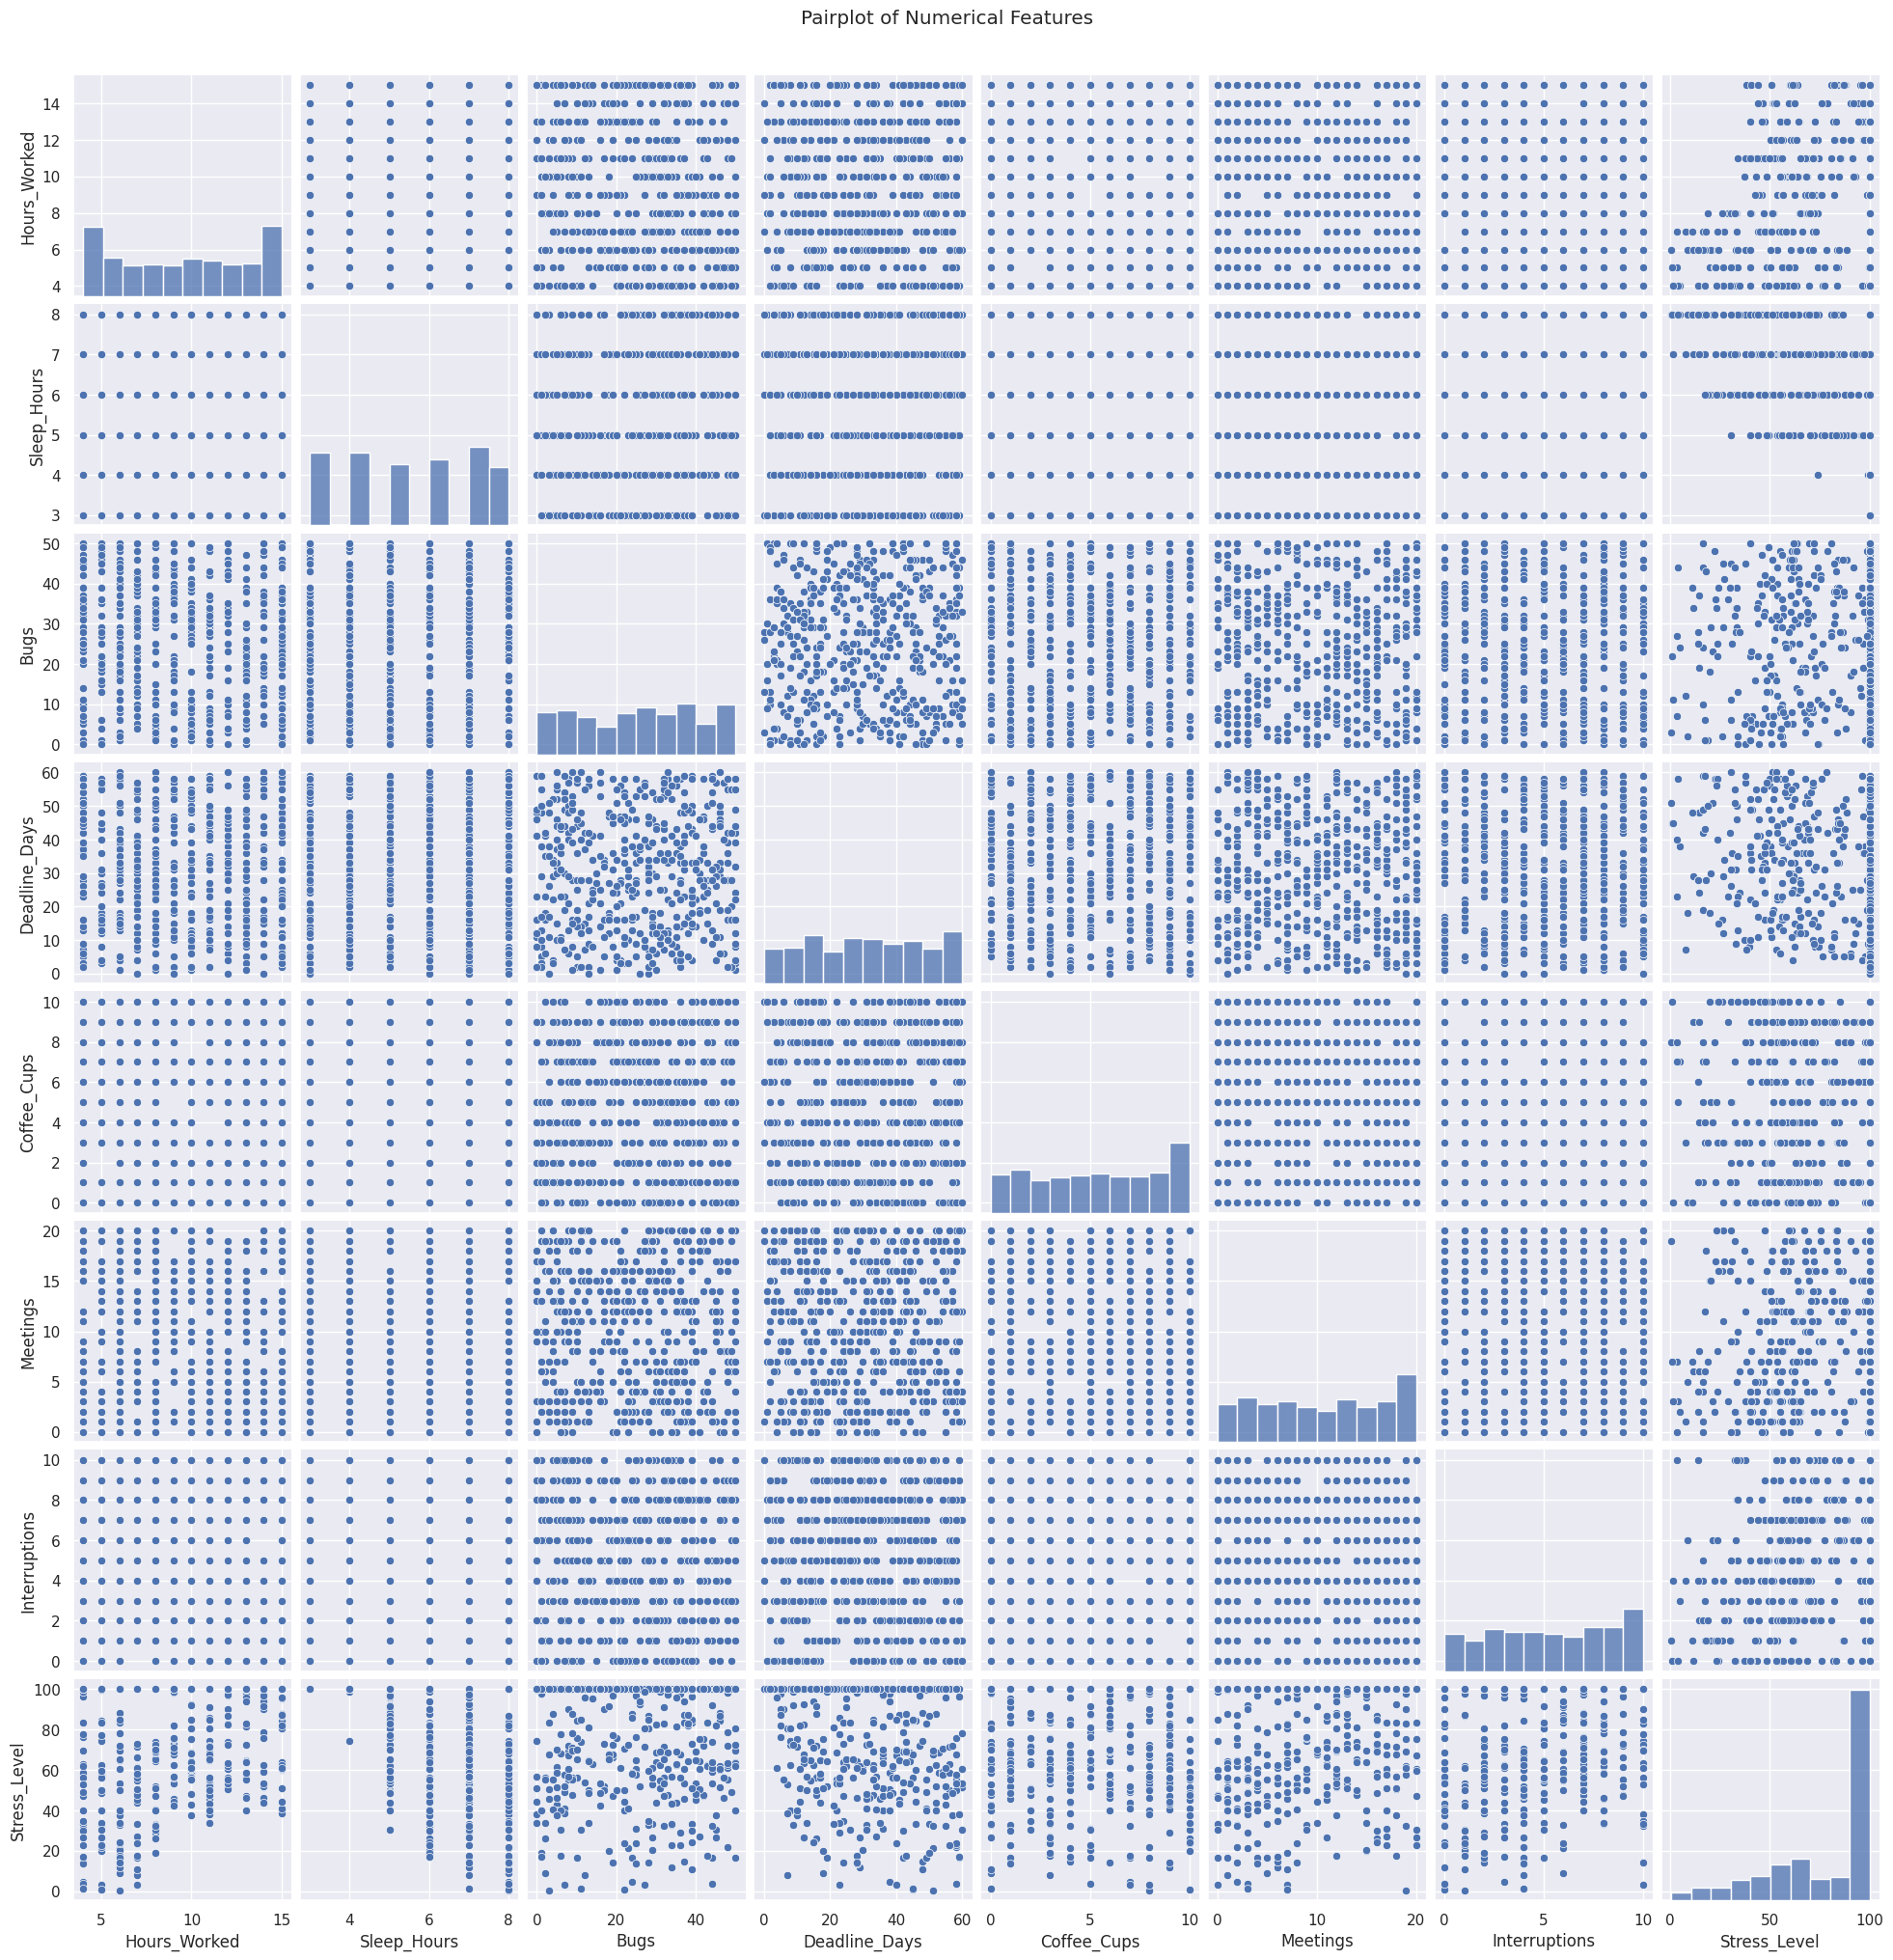

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

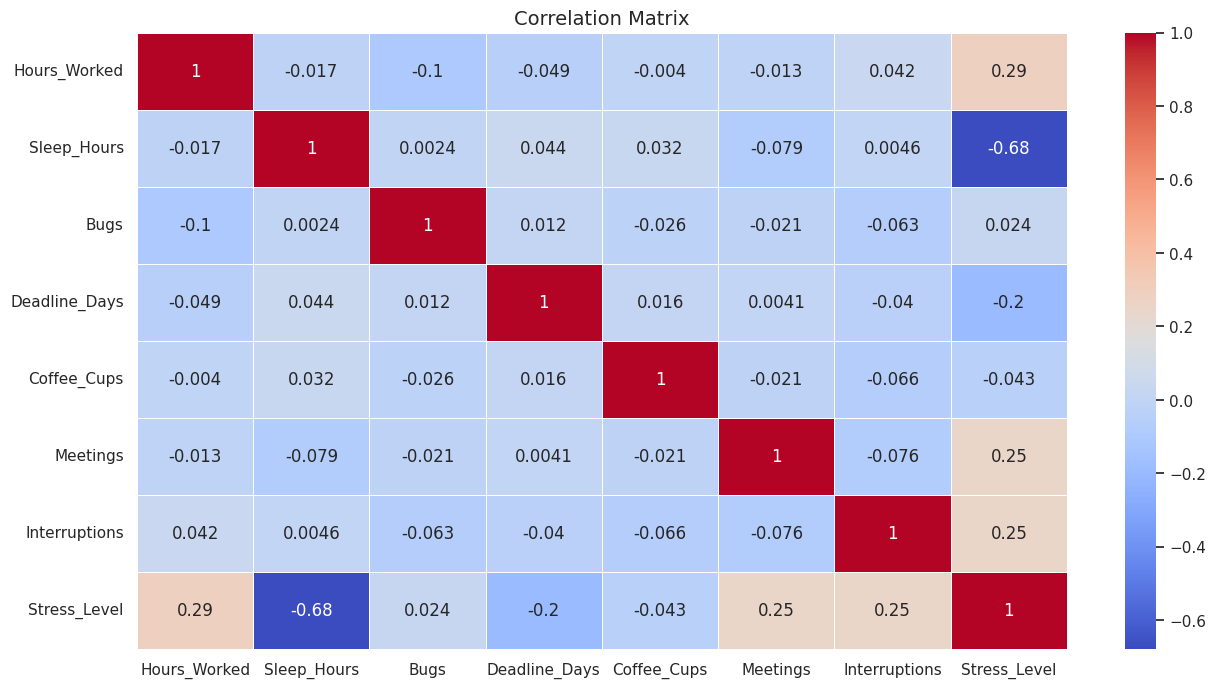

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Machine Learning

## Burnout Prediction Model & Feature Importance

--- Classification Report (Burnout Prediction) ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       100

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



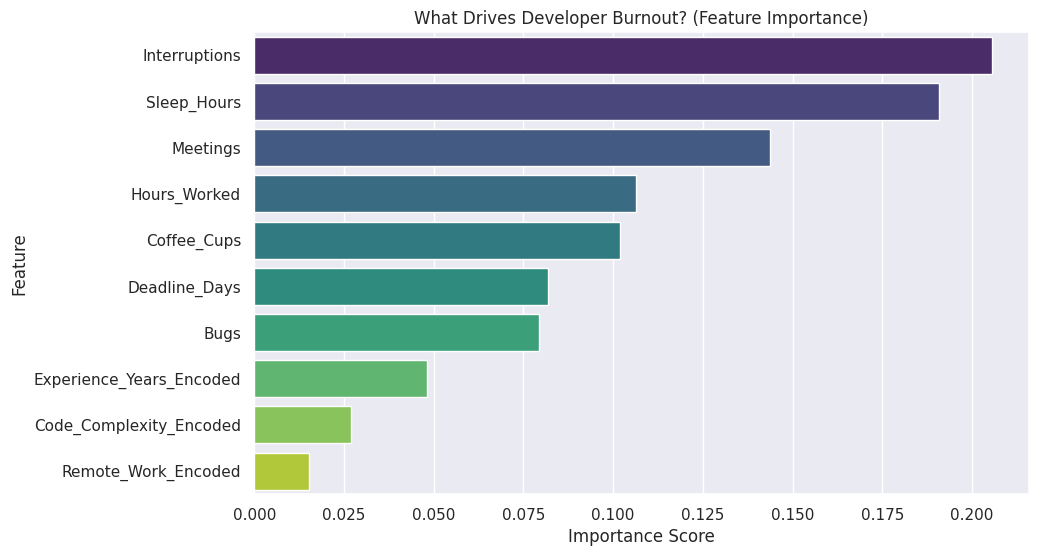

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Prepare the Data
# Create a copy to keep the original safe
df_ml = df.copy()

# Encode Categorical Variables (Turn text into numbers)
le = LabelEncoder()
cols_to_encode = ['Experience_Years', 'Code_Complexity', 'Remote_Work']
for col in cols_to_encode:
    df_ml[f'{col}_Encoded'] = le.fit_transform(df_ml[col])

# Create the Target Variable: "High Burnout Risk"
# We define "High Risk" as a Stress Level > 7 (on a scale of 1-10)
df_ml['Burnout_Risk'] = np.where(df_ml['Stress_Level'] >= 7, 1, 0)

# Define Features (X) and Target (y)
# We drop Stress_Level because that's the answer key!
feature_cols = ['Hours_Worked', 'Sleep_Hours', 'Bugs', 'Deadline_Days',
                'Coffee_Cups', 'Meetings', 'Interruptions',
                'Experience_Years_Encoded', 'Code_Complexity_Encoded', 'Remote_Work_Encoded']

X = df_ml[feature_cols]
y = df_ml['Burnout_Risk']

# 2. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Evaluate
y_pred = model.predict(X_test)
print("--- Classification Report (Burnout Prediction) ---")
print(classification_report(y_test, y_pred))

# 4. Feature Importance (The "Why")
# This tells us WHAT causes the stress
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('What Drives Developer Burnout? (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

## Clustering (Finding "Developer Personas")


--- Developer Personas (Average Stats per Cluster) ---
         Hours_Worked  Stress_Level       Bugs  Code_Complexity_Encoded
Cluster                                                                
0           10.653846     87.816142  28.109890                 0.219780
1            6.235294     49.116223  31.661765                 1.426471
2           10.796703     87.031562  17.324176                 1.741758


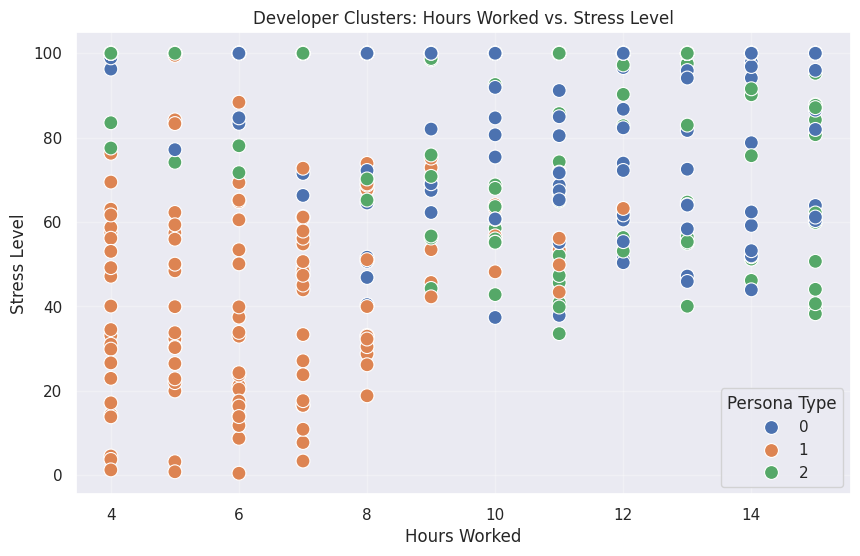

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select Features for Clustering
# Let's group developers based on their work habits and stress
cluster_cols = ['Hours_Worked', 'Stress_Level', 'Bugs', 'Code_Complexity_Encoded']
X_cluster = df_ml[cluster_cols].copy()

# 2. Scale the Data
# K-Means needs all data to be on the same scale (0-1 range approx)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Apply K-Means
# We will create 3 Clusters (Types of Developers)
kmeans = KMeans(n_clusters=3, random_state=42)
df_ml['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Interpret the Clusters
# Check the average stats for each group
print("\n--- Developer Personas (Average Stats per Cluster) ---")
print(df_ml.groupby('Cluster')[['Hours_Worked', 'Stress_Level', 'Bugs', 'Code_Complexity_Encoded']].mean())

# 5. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ml, x='Hours_Worked', y='Stress_Level',
                hue='Cluster', palette='deep', s=100)
plt.title('Developer Clusters: Hours Worked vs. Stress Level')
plt.xlabel('Hours Worked')
plt.ylabel('Stress Level')
plt.legend(title='Persona Type')
plt.grid(True, alpha=0.3)
plt.show()

# Thank You